In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# VinDR-CXR Dataset

### List of issues found:

1. Disagreement in radiologist: in some images, one radiologist agreed with "No Finding" while the others annotate certain pathologies. The example: **01a93e09220daa5b0316d426b701c76c**, **0d2e947bb475050c9039828b754ff6fa**, **12c57b0679d77f63009d79239f5cb1ba**. These images will take majority vote to decide the result
2. In the training dataset, every image have 3 result from different radiologist. In this matrix, we also do majority vote to decide the results
3. Please note that this is multi-label case, so all pathologies are not mutually exclusive
4. The list of pathologies and its total (after removing indication, as we focus on pathologies) is as follows:
- Aortic enlargement: 2566
- Atelectasis: 148
- Calcification: 371
- Cardiomegaly: 2126
- Clavicle fracture: 3
- Consolidation: 217
- Edema: 1
- Emphysema: 17
- Enlarged PA: 29
- ILD: 373
- Infiltration: 303
- Lung Opacity: 631
- Lung cavity: 29
- Lung cyst: 6
- Mediastinal shift: 105
- Nodule/Mass: 585
- Pleural effusion: 745
- Pleural thickening: 1051
- Pneumothorax: 76
- Pulmonary fibrosis: 1234
- Rib fracture: 52
- Other lesion: 456
- COPD: 9
- Lung tumor: 214
- Pneumonia: 717
- Tuberculosis: 646
- Other diseases: 4660
- No Finding: 12652

### Processing the dataframe for chest pathologies

In [3]:
def majority_vote(df, id_col: str = 'image_id'):
    # Preserve original column order
    original_cols = [col for col in df.columns if col != id_col]

    # Group by ID and sum the values
    summed = df.groupby(id_col)[original_cols].sum()

    # Get group sizes for majority threshold
    group_sizes = df.groupby(id_col).size()

    # Apply majority vote: 1 if count ≥ half the group size + 1
    majority = (summed.ge(group_sizes // 2 + 1, axis=0)).astype(int)

    # Reorder columns to match original
    majority = majority[original_cols]

    # Reset index to bring back the ID column
    return majority.reset_index()

In [4]:
# Load the data label directory files
csv_train_dir = r"vindr_image_labels_train.csv"
csv_test_dir = r"vindr_image_labels_test.csv"

train_sheet = pd.read_csv(csv_train_dir)
train_sheet = train_sheet.drop('rad_id', axis=1) #remove rad_id to give the same shape

test_sheet = pd.read_csv(csv_test_dir)
test_sheet = test_sheet.rename(columns={'Other disease': 'Other diseases'}) # rename the typo in column

combined_df = pd.concat([train_sheet, test_sheet], axis=0, ignore_index=True)
combined_df

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
0,000434271f63a053c4128a0ba6352c7f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,000434271f63a053c4128a0ba6352c7f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,000434271f63a053c4128a0ba6352c7f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,00053190460d56c53cc3e57321387478,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,00053190460d56c53cc3e57321387478,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,a039af299f86007d0d77da077a6def9a,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47996,aba3d1f5b1c04236f52a8980929b2cfa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47997,6d3d6b53f358a983b486e9e03144eb62,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47998,d6678cb7ae39f575d35ab9da6d7cb171,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
combined_df = pd.concat([train_sheet, test_sheet], axis=0, ignore_index=True)
combined_df

combined_df.to_csv('vindr_combined.csv', index=False)

In [6]:
combined__test_dir = r"vindr_combined.csv"

combined_train_sheet = pd.read_csv(combined__test_dir)
combined_train_sheet

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
0,000434271f63a053c4128a0ba6352c7f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,000434271f63a053c4128a0ba6352c7f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,000434271f63a053c4128a0ba6352c7f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,00053190460d56c53cc3e57321387478,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,00053190460d56c53cc3e57321387478,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,a039af299f86007d0d77da077a6def9a,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47996,aba3d1f5b1c04236f52a8980929b2cfa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47997,6d3d6b53f358a983b486e9e03144eb62,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47998,d6678cb7ae39f575d35ab9da6d7cb171,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
majority_vote_df = majority_vote(combined_train_sheet)

In [8]:
nofinding = majority_vote_df[majority_vote_df['No finding'] == 1]
len(nofinding)

12652

In [9]:
# remove "No Finding" from dataset

remove_nofinding = majority_vote_df[majority_vote_df['No finding'] != 1]
remove_nofinding

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
2,0005e8e3701dfb1dd93d53e2ff537b6e,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
4,0007d316f756b3fa0baea2ff514ce945,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
6,000d68e42b71d3eac10ccc077aba07c1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
7,00150343289f317a0ad5629d5b7d9ef9,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
9,001d127bad87592efe45a5c7678f8b8d,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17985,ffb5d0b005261ed350f7a08c06613a34,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17990,ffccf1709d0081d122a1d1f9edbefdf1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
17991,ffceb71a80efba3b83c88e11f4b9694b,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
17995,ffe6f9fe648a7ec29a50feb92d6c15a4,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Working on image that have differences in radiologist

In [10]:
# get one example

example = combined_df[combined_df['image_id'] == '01a93e09220daa5b0316d426b701c76c']
example

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
288,01a93e09220daa5b0316d426b701c76c,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
289,01a93e09220daa5b0316d426b701c76c,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
290,01a93e09220daa5b0316d426b701c76c,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [11]:
# get one example

example = combined_df[combined_df['image_id'] == '0d2e947bb475050c9039828b754ff6fa']
example

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
2292,0d2e947bb475050c9039828b754ff6fa,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2293,0d2e947bb475050c9039828b754ff6fa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2294,0d2e947bb475050c9039828b754ff6fa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [12]:
# get one example

example = combined_df[combined_df['image_id'] == 'f5258c6553ebe9557f5f79ba52428220']
example

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
43254,f5258c6553ebe9557f5f79ba52428220,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
43255,f5258c6553ebe9557f5f79ba52428220,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
43256,f5258c6553ebe9557f5f79ba52428220,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [13]:
# list of all images with radiologist differences

test_remove_nofinding = train_sheet[train_sheet['No finding'] != 1]
filtered = test_remove_nofinding[test_remove_nofinding['image_id'].map(test_remove_nofinding['image_id'].value_counts()) != 3]
image_id_filtered = filtered['image_id']
image_id_filtered

30       0021df30f3fddef551eb3df4354b1d06
289      01a93e09220daa5b0316d426b701c76c
338      01ce66ee84ef4045a06269aa0f5c2756
501      02f48a4f3bcfa77917203130505a12fc
722      042dafdd2ec468835d672cb01f5dd136
                       ...               
43049    f3eacf0f4778fcba5d17d0d2ed70f2e4
43256    f5258c6553ebe9557f5f79ba52428220
43579    f6ee38b0c52f354da0a6cb2bf106533e
44188    fab2ad94eb5bac3d71e0046a9787579a
44544    fce8ed512837977d28876bd24e3f8c85
Name: image_id, Length: 133, dtype: object

### Counting pathologies

In [14]:
# Combine value in the same pathology
remove_nofinding = remove_nofinding.copy()
remove_nofinding["Lung Opacity"] = remove_nofinding[["Lung Opacity", "Infiltration"]].max(axis=1)
remove_nofinding["Lung Lesion"] = remove_nofinding[["Nodule/Mass", "Lung cyst", "Lung cavity", "Lung tumor"]].max(axis=1)
remove_nofinding["Fracture"] = remove_nofinding[["Rib fracture", "Clavicle fracture"]].max(axis=1)

In [15]:
Aortic_enlargement = remove_nofinding['Aortic enlargement'].sum()
Atelectasis = remove_nofinding['Atelectasis'].sum()
Calcification = remove_nofinding['Calcification'].sum()
Cardiomegaly = remove_nofinding['Cardiomegaly'].sum()
Clavicle_fracture = remove_nofinding['Clavicle fracture'].sum()
Consolidation = remove_nofinding['Consolidation'].sum()
Edema = remove_nofinding['Edema'].sum()
Emphysema = remove_nofinding['Emphysema'].sum()
Enlarged_PA = remove_nofinding['Enlarged PA'].sum()
ILD = remove_nofinding['ILD'].sum()
Infiltration = remove_nofinding['Infiltration'].sum()
Lung_Opacity = remove_nofinding['Lung Opacity'].sum()
Lung_cavity = remove_nofinding['Lung cavity'].sum()
Lung_cyst = remove_nofinding['Lung cyst'].sum()
Mediastinal_shift = remove_nofinding['Mediastinal shift'].sum()
Nodule_Mass = remove_nofinding['Nodule/Mass'].sum()
Pleural_effusion = remove_nofinding['Pleural effusion'].sum()
Pleural_thickening = remove_nofinding['Pleural thickening'].sum()
Pneumothorax = remove_nofinding['Pneumothorax'].sum()
Pulmonary_fibrosis = remove_nofinding['Pulmonary fibrosis'].sum()
Rib_fracture = remove_nofinding['Rib fracture'].sum()
Other_lesion = remove_nofinding['Other lesion'].sum()
COPD = remove_nofinding['COPD'].sum()
Lung_tumor = remove_nofinding['Lung tumor'].sum()
Pneumonia = remove_nofinding['Pneumonia'].sum()
Tuberculosis = remove_nofinding['Tuberculosis'].sum()
Other_diseases = remove_nofinding['Other diseases'].sum()
Lung_Opacity = remove_nofinding['Lung Opacity'].sum()
Lung_Lesion = remove_nofinding['Lung Lesion'].sum()
Fracture = remove_nofinding['Fracture'].sum()


print('Aortic enlargement: ' + str(int(Aortic_enlargement)))
print('Atelectasis: ' + str(int(Atelectasis)))
print('Calcification: ' + str(int(Calcification)))
print('Cardiomegaly: ' + str(int(Cardiomegaly)))
print('Clavicle fracture: ' + str(int(Clavicle_fracture)))
print('Consolidation: ' + str(int(Consolidation)))
print('Edema: ' + str(int(Edema)))
print('Emphysema: ' + str(int(Emphysema)))
print('Enlarged PA: ' + str(int(Enlarged_PA)))
print('ILD: ' + str(int(ILD)))
print('Infiltration: ' + str(int(Infiltration)))
print('Lung Opacity: ' + str(int(Lung_Opacity)))
print('Lung cavity: ' + str(int(Lung_cavity)))
print('Lung cyst: ' + str(int(Lung_cyst)))
print('Mediastinal shift: ' + str(int(Mediastinal_shift)))
print('Nodule/Mass: ' + str(int(Nodule_Mass)))
print('Pleural effusion: ' + str(int(Pleural_effusion)))
print('Pleural thickening: ' + str(int(Pleural_thickening)))
print('Pneumothorax: ' + str(int(Pneumothorax)))
print('Pulmonary fibrosis: ' + str(int(Pulmonary_fibrosis)))
print('Rib fracture: ' + str(int(Rib_fracture)))
print('Other lesion: ' + str(int(Other_lesion)))
print('COPD: ' + str(int(COPD)))
print('Lung tumor: ' + str(int(Lung_tumor)))
print('Pneumonia: ' + str(int(Pneumonia)))
print('Tuberculosis: ' + str(int(Tuberculosis)))
print('Other diseases: ' + str(int(Other_diseases)))
print('Lung Opacity: ' + str(int(Lung_Opacity)))
print('Lung Lesion: ' + str(int(Lung_Lesion)))
print('Fracture: ' + str(int(Fracture)))

Aortic enlargement: 2566
Atelectasis: 148
Calcification: 371
Cardiomegaly: 2126
Clavicle fracture: 3
Consolidation: 217
Edema: 1
Emphysema: 17
Enlarged PA: 29
ILD: 373
Infiltration: 303
Lung Opacity: 850
Lung cavity: 29
Lung cyst: 6
Mediastinal shift: 105
Nodule/Mass: 585
Pleural effusion: 745
Pleural thickening: 1051
Pneumothorax: 76
Pulmonary fibrosis: 1234
Rib fracture: 52
Other lesion: 456
COPD: 9
Lung tumor: 214
Pneumonia: 717
Tuberculosis: 646
Other diseases: 4660
Lung Opacity: 850
Lung Lesion: 627
Fracture: 55


# CheXpert Dataset

### List of Issues & Consideration

1. We use the Visual ChexBert labeler to remove the uncertainty tags and also give the best performance
2. We only use the Frontal image (we remove the all rows with Lateral image)
3. We remove pneumonia as it's not included in our list of pathologies
4. Please note that this is multi-label case, so all pathologies are not mutually exclusive
5. The total pathologies recorded (after eliminating others) are as followed:
- No Finding: 35526
- Enlarged Cardiomediastinum: 130885
- Cardiomegaly: 111129
- Lung Opacity: 137293
- Lung Lesion: 26730
- Edema: 88569
- Consolidation: 97917
- Atelectasis: 112167
- Pneumothorax: 21977
- Pleural Effusion: 93081
- Pleural Other: 15594
- Fracture: 44878
- Support Devices: 124696
- Pneumonia: 50574

### Processing the dataframe for chest pathologies

In [121]:
# Load the data label directory files
csv_dir = r"chexpert_train_visualCheXbert.csv"

image_sheet = pd.read_csv(csv_dir)
image_sheet

,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,CheXpert-v1.0/train/patient00002/study1/view2_...,Female,83,Lateral,NaN,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,CheXpert-v1.0/train/patient64537/study2/view1_...,Male,59,Frontal,AP,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
223410,CheXpert-v1.0/train/patient64537/study1/view1_...,Male,59,Frontal,AP,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
223411,CheXpert-v1.0/train/patient64538/study1/view1_...,Female,0,Frontal,AP,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
223412,CheXpert-v1.0/train/patient64539/study1/view1_...,Female,0,Frontal,AP,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [25]:
nofinding = image_sheet[image_sheet['No Finding'] == 1]
len(nofinding)

35526

In [ ]:
# filtered_lateral = image_sheet[image_sheet['Frontal/Lateral'] != 'Lateral'] # Remove lateral images
filtered_lateral_nofinding = image_sheet[image_sheet['No Finding'] != 1] # Remove No finding images

# Filter the table to only include focused pathologies
focused_pathologies = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'Pneumonia']
duplicate_filtered_lateral_nofinding = filtered_lateral_nofinding[focused_pathologies]
duplicate_filtered_lateral_nofinding

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,Pneumonia
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
3,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
4,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
223410,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0
223411,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
223412,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
Enlarged_Cardiomediastinum = duplicate_filtered_lateral_nofinding['Enlarged Cardiomediastinum'].sum()
Cardiomegaly = duplicate_filtered_lateral_nofinding['Cardiomegaly'].sum()
Lung_Opacity = duplicate_filtered_lateral_nofinding['Lung Opacity'].sum()
Lung_Lesion	 = duplicate_filtered_lateral_nofinding['Lung Lesion'].sum()
Edema = duplicate_filtered_lateral_nofinding['Edema'].sum()
Consolidation = duplicate_filtered_lateral_nofinding['Consolidation'].sum()
Atelectasis = duplicate_filtered_lateral_nofinding['Atelectasis'].sum()
Pneumothorax = duplicate_filtered_lateral_nofinding['Pneumothorax'].sum()
Pleural_Effusion = duplicate_filtered_lateral_nofinding['Pleural Effusion'].sum()
Pleural_Other = duplicate_filtered_lateral_nofinding['Pleural Other'].sum()
Fracture = duplicate_filtered_lateral_nofinding['Fracture'].sum()
Support_Devices = duplicate_filtered_lateral_nofinding['Support Devices'].sum()
Pneumonia = duplicate_filtered_lateral_nofinding['Pneumonia'].sum()

print('Enlarged Cardiomediastinum: ' + str(int(Enlarged_Cardiomediastinum)))
print('Cardiomegaly: ' + str(int(Cardiomegaly)))
print('Lung Opacity: ' + str(int(Lung_Opacity)))
print('Lung Lesion: ' + str(int(Lung_Lesion)))
print('Edema: ' + str(int(Edema)))
print('Consolidation: ' + str(int(Consolidation)))
print('Atelectasis: ' + str(int(Atelectasis)))
print('Pneumothorax: ' + str(int(Pneumothorax)))
print('Pleural Effusion: ' + str(int(Pleural_Effusion)))
print('Pleural Other: ' + str(int(Pleural_Other)))
print('Fracture: ' + str(int(Fracture)))
print('Support Devices: ' + str(int(Support_Devices)))
print('Pneumonia: ' + str(int(Pneumonia)))

Enlarged Cardiomediastinum: 143490
Cardiomegaly: 121482
Lung Opacity: 151429
Lung Lesion: 29769
Edema: 94357
Consolidation: 106964
Atelectasis: 123846
Pneumothorax: 24363
Pleural Effusion: 103473
Pleural Other: 21898
Fracture: 55452
Support Devices: 134885
Pneumonia: 50574


# MIMIC-CXR Dataset

### List of Issues & Consideration

1. We use the CheXpert to label the result for the dataset
2. Please note that this is multi-label case, so all pathologies are not mutually exclusive
3. The total pathologies recorded (after eliminating others) are as followed:
- No Finding: 75455
- Enlarged Cardiomediastinum: 7179
- Cardiomegaly: 44845
- Lung Opacity: 51525
- Lung Lesion: 6284
- Edema: 27018
- Consolidation: 10778
- Atelectasis: 45808
- Pneumothorax: 10358
- Pleural Effusion: 54300
- Pleural Other: 2011
- Fracture: 4390
- Support Devices: 66558
- Pneumonias: 16556

### Processing the dataframe for chest pathologies

In [120]:
# Load the data label directory files
csv_dir = r"mimic_cxr_2-0-0-chexpert.csv"

image_sheet = pd.read_csv(csv_dir)
image_sheet = image_sheet.fillna(0)

image_sheet

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,10000032,53189527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,10000032,53911762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,10000032,56699142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,10000764,57375967,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,19999442,58708861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
227823,19999733,57132437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
227824,19999987,55368167,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
227825,19999987,58621812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [28]:
nofinding = image_sheet[image_sheet['No Finding'] == 1]
len(nofinding)

75455

In [29]:
#filtered_nofinding = image_sheet[image_sheet['No Finding'] != 1] # Remove No finding images

# Filter the table to only include focused pathologies
#focused_pathologies = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'Pneumonia']
#mimic_duplicate_filtered_nofinding = filtered_nofinding[focused_pathologies]
mimic_duplicate_filtered_nofinding = image_sheet
mimic_duplicate_filtered_nofinding = mimic_duplicate_filtered_nofinding.replace(-1, 0)
mimic_duplicate_filtered_nofinding

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,10000032,53189527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,10000032,53911762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,10000032,56699142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,10000764,57375967,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,19999442,58708861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
227823,19999733,57132437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
227824,19999987,55368167,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
227825,19999987,58621812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [30]:
No_Finding = mimic_duplicate_filtered_nofinding['No Finding'].sum()
Enlarged_Cardiomediastinum = mimic_duplicate_filtered_nofinding['Enlarged Cardiomediastinum'].sum()
Cardiomegaly = mimic_duplicate_filtered_nofinding['Cardiomegaly'].sum()
Lung_Opacity = mimic_duplicate_filtered_nofinding['Lung Opacity'].sum()
Lung_Lesion	 = mimic_duplicate_filtered_nofinding['Lung Lesion'].sum()
Edema = mimic_duplicate_filtered_nofinding['Edema'].sum()
Consolidation = mimic_duplicate_filtered_nofinding['Consolidation'].sum()
Atelectasis = mimic_duplicate_filtered_nofinding['Atelectasis'].sum()
Pneumothorax = mimic_duplicate_filtered_nofinding['Pneumothorax'].sum()
Pleural_Effusion = mimic_duplicate_filtered_nofinding['Pleural Effusion'].sum()
Pleural_Other = mimic_duplicate_filtered_nofinding['Pleural Other'].sum()
Fracture = mimic_duplicate_filtered_nofinding['Fracture'].sum()
Support_Devices = mimic_duplicate_filtered_nofinding['Support Devices'].sum()
Pneumonia = mimic_duplicate_filtered_nofinding['Pneumonia'].sum()

print('No Finding: ' + str(int(No_Finding)))
print('Enlarged Cardiomediastinum: ' + str(int(Enlarged_Cardiomediastinum)))
print('Cardiomegaly: ' + str(int(Cardiomegaly)))
print('Lung Opacity: ' + str(int(Lung_Opacity)))
print('Lung Lesion: ' + str(int(Lung_Lesion)))
print('Edema: ' + str(int(Edema)))
print('Consolidation: ' + str(int(Consolidation)))
print('Atelectasis: ' + str(int(Atelectasis)))
print('Pneumothorax: ' + str(int(Pneumothorax)))
print('Pleural Effusion: ' + str(int(Pleural_Effusion)))
print('Pleural Other: ' + str(int(Pleural_Other)))
print('Fracture: ' + str(int(Fracture)))
print('Support Devices: ' + str(int(Support_Devices)))
print('Pneumonias: ' + str(int(Pneumonia)))

No Finding: 75455
Enlarged Cardiomediastinum: 7179
Cardiomegaly: 44845
Lung Opacity: 51525
Lung Lesion: 6284
Edema: 27018
Consolidation: 10778
Atelectasis: 45808
Pneumothorax: 10358
Pleural Effusion: 54300
Pleural Other: 2011
Fracture: 4390
Support Devices: 66558
Pneumonias: 16556


In [31]:
focused_pathologies = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'Pneumonia']
mimic_comorbidities = image_sheet[focused_pathologies]

In [32]:
mimic_comorbidities = mimic_comorbidities.replace(-1, 0)
mimic_comorbidities

,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,Pneumonia
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
227823,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
227824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
227825,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# NIH ChestXRay-14

### List of Issues & Consideration

1. We use the chestxray14 data entry competition files
2. Please note that this is multi-label case, so all pathologies are not mutually exclusive
3. The total pathologies recorded (after eliminating others) are as followed:
- No Finding: 60361
- Cardiomegaly: 2776
- Hernia: 227
- Mass: 5782
- Infiltration: 19894
- Effusion: 13317
- Nodule: 6331
- Emphysema: 2516
- Atelectasis: 11559
- Pleural Thickening: 3385
- Pneumothorax: 5302
- Fibrosis: 1686
- Consolidation: 4667
- Edema: 2303
- Pneumonia: 1431

### Processing the dataframe for chest pathologies

In [35]:
# Load the data label directory files
csv_dir = r"nih_chestxray14_Data_Entry_2017.csv"

image_sheet = pd.read_csv(csv_dir)

image_sheet

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168,0.168,NaN
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168,0.168,NaN
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,0.168,NaN
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168,0.168,NaN


In [36]:
nofinding = image_sheet[image_sheet['Finding Labels'] == 'No Finding']
len(nofinding)

60361

In [37]:
# Remove the "No finding" from the table

filtered_nofinding = image_sheet[image_sheet['Finding Labels'] != 'No Finding'] # Remove No finding images
filtered_nofinding

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143000,0.143000,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143000,0.143000,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168000,0.168000,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143000,0.143000,NaN
5,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168000,0.168000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
112097,00030786_007.png,Consolidation|Pleural_Thickening,7,30786,61,F,AP,3056,2544,0.139000,0.139000,NaN
112100,00030789_000.png,Infiltration,0,30789,52,F,PA,2021,2021,0.194311,0.194311,NaN
112106,00030793_000.png,Mass|Nodule,0,30793,58,F,PA,2021,2021,0.194311,0.194311,NaN
112108,00030795_000.png,Pleural_Thickening,0,30795,53,F,PA,2021,2021,0.194311,0.194311,NaN


In [38]:
# Filter the labels as several columns after symbol "|"
split_filtered_nofinding = image_sheet['Finding Labels'].str.split('|', expand=True)
split_filtered_nofinding.columns = [f'tag_{i+1}' for i in range(split_filtered_nofinding.shape[1])]
image_sheet = image_sheet.join(split_filtered_nofinding)

# Filter out unnecessary columns
column_kept = ['Image Index', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
duplicate_filtered_nofinding = image_sheet[column_kept]

duplicate_filtered_nofinding

,Image Index,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,00000001_000.png,Cardiomegaly,None,None,None,None,None,None,None
1,00000001_001.png,Cardiomegaly,Emphysema,None,None,None,None,None,None
2,00000001_002.png,Cardiomegaly,Effusion,None,None,None,None,None,None
3,00000002_000.png,No Finding,None,None,None,None,None,None,None
4,00000003_000.png,Hernia,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass,Pneumonia,None,None,None,None,None,None
112116,00030802_000.png,No Finding,None,None,None,None,None,None,None
112117,00030803_000.png,No Finding,None,None,None,None,None,None,None
112118,00030804_000.png,No Finding,None,None,None,None,None,None,None


In [39]:
# Get all unique values for list of possible pathologies

unique_values = duplicate_filtered_nofinding['tag_1'].unique().tolist()

columns_to_check = ['tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

for col in columns_to_check:
    for value in duplicate_filtered_nofinding[col]:
        if value not in unique_values:
            unique_values.append(value)

print(unique_values)

['Cardiomegaly', 'No Finding', 'Hernia', 'Mass', 'Infiltration', 'Effusion', 'Nodule', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Pneumothorax', 'Fibrosis', 'Consolidation', 'Edema', 'Pneumonia', None]


In [48]:
final_sheet = image_sheet.copy()

for col in unique_values:
    final_sheet.loc[:, col] = final_sheet['Finding Labels'].apply(
        lambda x: 1 if col in str(x).split('|') else 0
    )

# Filter out unnecessary columns
column_kept = ['No Finding', 'Cardiomegaly', 'Hernia', 'Mass', 'Infiltration', 'Effusion', 'Nodule', 'Emphysema', 'Atelectasis', 'Pleural_Thickening', 'Pneumothorax', 'Fibrosis', 'Consolidation', 'Edema', 'Pneumonia']
nih_final_sheet = final_sheet[column_kept]
nih_final_sheet

,No Finding,Cardiomegaly,Hernia,Mass,Infiltration,Effusion,Nodule,Emphysema,Atelectasis,Pleural_Thickening,Pneumothorax,Fibrosis,Consolidation,Edema,Pneumonia
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
2,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112115,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
112116,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
112117,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
112118,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
Cardiomegaly = nih_final_sheet['Cardiomegaly'].sum()
Hernia = nih_final_sheet['Hernia'].sum()
Mass = nih_final_sheet['Mass'].sum()
Infiltration = nih_final_sheet['Infiltration'].sum()
Effusion = nih_final_sheet['Effusion'].sum()
Nodule = nih_final_sheet['Nodule'].sum()
Emphysema = nih_final_sheet['Emphysema'].sum()
Atelectasis = nih_final_sheet['Atelectasis'].sum()
Pleural_Thickening = nih_final_sheet['Pleural_Thickening'].sum()
Pneumothorax = nih_final_sheet['Pneumothorax'].sum()
Fibrosis = nih_final_sheet['Fibrosis'].sum()
Consolidation = nih_final_sheet['Consolidation'].sum()
Edema = nih_final_sheet['Edema'].sum()
Pneumonia = nih_final_sheet['Pneumonia'].sum()

print('Cardiomegaly: ' + str(int(Cardiomegaly)))
print('Hernia: ' + str(int(Hernia)))
print('Mass: ' + str(int(Mass)))
print('Infiltration: ' + str(int(Infiltration)))
print('Effusion: ' + str(int(Effusion)))
print('Nodule: ' + str(int(Nodule)))
print('Emphysema: ' + str(int(Emphysema)))
print('Atelectasis: ' + str(int(Atelectasis)))
print('Pleural Thickening: ' + str(int(Pleural_Thickening)))
print('Pneumothorax: ' + str(int(Pneumothorax)))
print('Fibrosis: ' + str(int(Fibrosis)))
print('Consolidation: ' + str(int(Consolidation)))
print('Edema: ' + str(int(Edema)))
print('Pneumonia: ' + str(int(Pneumonia)))

Cardiomegaly: 2776
Hernia: 227
Mass: 5782
Infiltration: 19894
Effusion: 13317
Nodule: 6331
Emphysema: 2516
Atelectasis: 11559
Pleural Thickening: 3385
Pneumothorax: 5302
Fibrosis: 1686
Consolidation: 4667
Edema: 2303
Pneumonia: 1431


# Padchest Dataset

### List of Issues & Consideration
The case is tricky as there are 350 cases, we need to decide which one to choose

### Processing the dataframe for chest pathologies

In [164]:
def merge_case_insensitive_columns(df):
    # Map lowercase column names to their original variants
    col_map = {}
    for col in df.columns:
        key = col.lower()
        col_map.setdefault(key, []).append(col)

    # Build merged columns
    merged_cols = []
    for key, variants in col_map.items():
        if len(variants) == 1:
            col = df[variants[0]].copy()
            col.name = variants[0]
        else:
            col = df[variants].max(axis=1)
            col.name = key.title()
        merged_cols.append(col)

    # Concatenate all columns at once to avoid fragmentation
    merged_df = pd.concat(merged_cols, axis=1)

    return merged_df

In [165]:
# Load the data label directory files
csv_dir = r"padchest_chest_x_ray_images_labels_160K_01.02.19.csv"

image_sheet = pd.read_csv(csv_dir)

image_sheet

,Unnamed: 0,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,...,ExposureTime,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,...,10.0,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[]
1,1,135803415504923515076821959678074435083_fzis7d...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,LATERAL,L,...,25.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
2,2,135803415504923515076821959678074435083_fzis7b...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,POSTEROANTERIOR,PA,...,10.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
3,3,113855343774216031107737439268243531979_3k951l...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,POSTEROANTERIOR,PA,...,8.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
4,4,113855343774216031107737439268243531979_3k951n...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,LATERAL,L,...,20.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160856,160856,1284011361929414522814654121696751542351444145...,49,20110321,1284011361929414522814654121696751542351444145...,112930952416074060371371014599496493673,1948.0,M,POSTEROANTERIOR,PA,...,10.0,-0.69,4018689,import sign radiolog epoc . pinzamient ambos ...,RNN_model,"['COPD signs', 'costophrenic angle blunting']",['loc costophrenic angle'],"['COPD signs', 'costophrenic angle blunting', ...",['C0024117' 'C0742855'],['C0230151']
160857,160857,1284011361929414522094646571696751542351444145...,49,20090609,1284011361929414522094646571696751542351444145...,282743729971423358706056731890510600934,1944.0,F,POSTEROANTERIOR,PA,...,10.0,-0.85,3639865,dentr normal .,RNN_model,['normal'],[],['normal'],[],[]
160858,160858,1284011361929414522086390631696751542351444145...,49,20110415,1284011361929414522086390631696751542351444145...,52648743308541843883453242716226652771,1965.0,M,NaN,AP_horizontal,...,NaN,784.00,4035503,tub endotraqueal sond nasogastr situacion cor...,RNN_model,"['NSG tube', ' endotracheal tube']",['loc tracheal'],"['NSG tube', ' endotracheal tube', 'loc trache...",['C0336630'],['C0040578']
160859,160859,1284011361929414522084108901696751542351444145...,49,20101214,1284011361929414522084108901696751542351444145...,228646130593152933811948996634154201216,1943.0,F,POSTEROANTERIOR,PA,...,10.0,-1.00,3958189,dentr normal .,RNN_model,['normal'],[],['normal'],[],[]


In [166]:
nofinding = image_sheet[image_sheet['Labels'] == "['normal']"]
len(nofinding)

50340

In [167]:
# Filter out unnecessary columns
column_kept = ['ImageID', 'ImageDir', 'Projection', 'Labels']
filter_sheet = image_sheet[column_kept]

# Filter out Lateral images and "No Finding"
padchest_filtered_nofinding = filter_sheet[filter_sheet['Labels'] != "['normal']"] # Remove No finding images
padchest_filtered_nofinding

,ImageID,ImageDir,Projection,Labels
1,135803415504923515076821959678074435083_fzis7d...,0,L,"['pulmonary fibrosis', 'chronic changes', 'kyp..."
2,135803415504923515076821959678074435083_fzis7b...,0,PA,"['pulmonary fibrosis', 'chronic changes', 'kyp..."
3,113855343774216031107737439268243531979_3k951l...,0,PA,['chronic changes']
4,113855343774216031107737439268243531979_3k951n...,0,L,['chronic changes']
5,313903302629300007485735352869488750471_75sg0k...,0,AP,"['unchanged', 'alveolar pattern', 'interstitia..."
...,...,...,...,...
160850,1284011361929414524678386411696751542351444145...,49,PA,['cardiomegaly']
160855,1284011361929414522814654121696751542351444145...,49,L,"['COPD signs', 'costophrenic angle blunting']"
160856,1284011361929414522814654121696751542351444145...,49,PA,"['COPD signs', 'costophrenic angle blunting']"
160858,1284011361929414522086390631696751542351444145...,49,AP_horizontal,"['NSG tube', ' endotracheal tube']"


In [168]:
# Break down all the labels with one-hot Encoding
import ast

# Step 1: Convert stringified lists to actual Python lists
padchest_filtered_nofinding = padchest_filtered_nofinding.copy()
padchest_filtered_nofinding['Labels'] = padchest_filtered_nofinding['Labels'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Step 2: Expand into binary columns
expanded_sheet = padchest_filtered_nofinding['Labels'].apply(lambda x: pd.Series(1, index=x)).fillna(0)

# Step 3: Merge with original DataFrame
padchest_final_sheet = padchest_filtered_nofinding.drop(columns='Labels').join(expanded_sheet)

padchest_final_sheet

,ImageID,ImageDir,Projection,pulmonary fibrosis,chronic changes,kyphosis,pseudonodule,ground glass pattern,unchanged,alveolar pattern,...,gastrostomy tube,round atelectasis,aortic endoprosthesis,azygoesophageal recess shift,catheter,subacromial space narrowing,central venous catheter via umbilical vein,pleural plaques,asbestosis signs,mastectomy
1,135803415504923515076821959678074435083_fzis7d...,0,L,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,135803415504923515076821959678074435083_fzis7b...,0,PA,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,113855343774216031107737439268243531979_3k951l...,0,PA,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,113855343774216031107737439268243531979_3k951n...,0,L,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,313903302629300007485735352869488750471_75sg0k...,0,AP,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160850,1284011361929414524678386411696751542351444145...,49,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160855,1284011361929414522814654121696751542351444145...,49,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160856,1284011361929414522814654121696751542351444145...,49,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160858,1284011361929414522086390631696751542351444145...,49,AP_horizontal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [169]:
# Selecting only several pathologies that we focus on

padchest_final_sheet = padchest_final_sheet.drop(['ImageID', 'ImageDir', 'Projection'], axis=1)

In [170]:
# Check duplicates causes by space -- eg. "fracture" and " fracture"

# Strip column names to normalize
padchest_final_sheet.columns = padchest_final_sheet.columns.str.strip()

# Track original column names before stripping
original_cols = padchest_final_sheet.columns.tolist()
raw_cols = padchest_final_sheet.columns.str.strip().tolist()

# Find duplicates caused by spacing
from collections import Counter
col_counts = Counter(raw_cols)

# Merge columns with same stripped name
for col in col_counts:
    if col_counts[col] > 1:
        # Find all variants of this column name
        variants = [c for c in original_cols if c.strip() == col]
        # Merge them: 1 if any variant is 1, else 0
        padchest_final_sheet[col] = padchest_final_sheet[variants].fillna(0).astype(int).max(axis=1)
        # Drop all but one
        to_drop = [c for c in variants if c != col]
        padchest_final_sheet.drop(columns=to_drop, inplace=True)

In [171]:
padchest_final_sheet = merge_case_insensitive_columns(padchest_final_sheet)
padchest_final_sheet

,Pulmonary Fibrosis,Chronic Changes,Kyphosis,Pseudonodule,Ground Glass Pattern,Unchanged,Alveolar Pattern,Interstitial Pattern,Laminar Atelectasis,Pleural Effusion,...,Catheter,Surgery Humeral,empyema,nephrostomy tube,sternoclavicular junction hypertrophy,Pulmonary Venous Hypertension,Gastrostomy Tube,lipomatosis,,normal
1,1,1,1,1,1,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
2,1,1,1,1,1,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
5,0,0,0,0,0,1,1,1,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160850,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
160855,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
160856,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
160858,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0


In [172]:
to_csv = pd.DataFrame(zip(padchest_final_sheet.columns.tolist()), columns = ['type'])
to_csv.to_csv('padchest_list.csv', index=False, header=False)

In [173]:
# Loading pre-processed CSV
padchest_datasheet_final = pd.read_csv('padchest_list_final_chexpert.csv', header=None, index_col=False)
padchest_datasheet_final = padchest_datasheet_final.T
padchest_datasheet_final.columns = padchest_datasheet_final.iloc[0]
padchest_datasheet_final = padchest_datasheet_final[1:].reset_index(drop=True)
padchest_datasheet_final

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,...,Asbestosis Signs,Pulmonary Hypertension,Post Radiotherapy Changes,Pectum Excavatum,Tracheal Shift,Calcified Fibroadenoma,Respiratory Distress,Azygoesophageal Recess Shift,Lung Vascular Paucity,Pneumoperitoneo


### Counting Pathologies

In [174]:
padchest_final_sheet

,Pulmonary Fibrosis,Chronic Changes,Kyphosis,Pseudonodule,Ground Glass Pattern,Unchanged,Alveolar Pattern,Interstitial Pattern,Laminar Atelectasis,Pleural Effusion,...,Catheter,Surgery Humeral,empyema,nephrostomy tube,sternoclavicular junction hypertrophy,Pulmonary Venous Hypertension,Gastrostomy Tube,lipomatosis,,normal
1,1,1,1,1,1,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
2,1,1,1,1,1,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
5,0,0,0,0,0,1,1,1,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160850,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
160855,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
160856,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
160858,0,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0


In [175]:
# Merge the columns to avoid double counting
padchest_final_sheet["Pneumonia"] = padchest_final_sheet[["Pneumonia", "Atypical Pneumonia"]].max(axis=1)
padchest_final_sheet["Pneumothorax"] = padchest_final_sheet[["Pneumothorax", "air fluid level", "Hydropneumothorax"]].max(axis=1)
padchest_final_sheet["Atelectasis"] = padchest_final_sheet[["Atelectasis", "Laminar Atelectasis", "Segmental Atelectasis", "Lobar Atelectasis", "atelectasis basal", "Total Atelectasis", "Round Atelectasis", "Flattened Diaphragm", "Volume Loss", "hypoexpansion basal", "Hypoexpansion"]].max(axis=1)
padchest_final_sheet["Cardiomegaly"] = padchest_final_sheet[["Cardiomegaly", "Heart Insufficiency"]].max(axis=1)
padchest_final_sheet["Pulmonary Edema"] = padchest_final_sheet[["Pulmonary Edema", "Kerley Lines"]].max(axis=1)
padchest_final_sheet["Infiltrates"] = padchest_final_sheet[["Infiltrates", "Alveolar Pattern", "Interstitial Pattern", "Ground Glass Pattern", "Reticulonodular Interstitial Pattern", "Reticular Interstitial Pattern", "Bronchovascular Markings", "Miliary Opacities"]].max(axis=1)
padchest_final_sheet["Pulmonary Mass"] = padchest_final_sheet[["Pulmonary Mass", "Mass", "Soft Tissue Mass", "pleural mass", "Nodule", "Multiple Nodules", "Cavitation", "Calcified Adenopathy", "Lymphangitis Carcinomatosa", "Lepidic Adenocarcinoma", "Bone Metastasis", "Lung Metastasis", "Tuberculosis Sequelae", "Pulmonary Fibrosis", "Calcified Granuloma", "Granuloma", "cyst"]].max(axis=1)
padchest_final_sheet["Pleural Thickening"] = padchest_final_sheet[["Pleural Thickening", "Calcified Pleural Thickening", "Apical Pleural Thickening", "Major Fissure Thickening", "Minor Fissure Thickening", "Fissure Thickening", "Pleural Plaques", "Calcified Pleural Plaques", "Diaphragmatic Eventration"]].max(axis=1)
padchest_final_sheet["Pleural Effusion"] = padchest_final_sheet[["Pleural Effusion", "Loculated Fissural Effusion"]].max(axis=1)
padchest_final_sheet["Endotracheal Tube"] = padchest_final_sheet[["Endotracheal Tube", "Tracheostomy Tube", "NSG tube", "Single Chamber Device", "Dual Chamber Device", "Electrical Device", "Central Venous Catheter Via Subclavian Vein", "Central Venous Catheter", "Reservoir Central Venous Catheter", "Central Venous Catheter Via Jugular Vein", "Central Venous Catheter Via Umbilical Vein", "Catheter", "double J stent", "Chest Drain Tube", "Gastrostomy Tube", "Ventriculoperitoneal Drain Tube", "Artificial Heart Valve", "Artificial Mitral Heart Valve", "Artificial Aortic Heart Valve", "Pacemaker", "bone cement", "endoprosthesis", "Aortic Endoprosthesis"]].max(axis=1)
padchest_final_sheet["fracture"] = padchest_final_sheet[["fracture", "Clavicle Fracture", "Callus Rib Fracture", "Humeral Fracture", "Vertebral Fracture", "Rib Fracture"]].max(axis=1)
padchest_final_sheet["Aortic Elongation"] = padchest_final_sheet[["Aortic Elongation", "Supra Aortic Elongation", "Descendent Aortic Elongation", "Ascendent Aortic Elongation", "Mediastinal Enlargement", "Pulmonary Artery Enlargement", "Aortic Button Enlargement", "Superior Mediastinal Enlargement", "Mediastinal Shift"]].max(axis=1)
padchest_final_sheet["abnormal foreign body"] = padchest_final_sheet[["abnormal foreign body", "External Foreign Body", "Metal", "Suture Material", "Osteosynthesis Material"]].max(axis=1)

# Drop combined columns
padchest_final_sheet = padchest_final_sheet.drop(columns=["Atypical Pneumonia"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["air fluid level", "Hydropneumothorax"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Laminar Atelectasis", "Segmental Atelectasis", "Lobar Atelectasis", "atelectasis basal", "Total Atelectasis", "Round Atelectasis", "Flattened Diaphragm", "Volume Loss", "hypoexpansion basal", "Hypoexpansion"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Heart Insufficiency"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Kerley Lines"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Alveolar Pattern", "Interstitial Pattern", "Ground Glass Pattern", "Reticulonodular Interstitial Pattern", "Reticular Interstitial Pattern", "Bronchovascular Markings", "Miliary Opacities"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Mass", "Soft Tissue Mass", "pleural mass", "Nodule", "Multiple Nodules", "Cavitation", "Calcified Adenopathy", "Lymphangitis Carcinomatosa", "Lepidic Adenocarcinoma", "Bone Metastasis", "Lung Metastasis", "Tuberculosis Sequelae", "Pulmonary Fibrosis", "Calcified Granuloma", "Granuloma", "cyst"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Calcified Pleural Thickening", "Apical Pleural Thickening", "Major Fissure Thickening", "Minor Fissure Thickening", "Fissure Thickening", "Pleural Plaques", "Calcified Pleural Plaques", "Diaphragmatic Eventration"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Loculated Fissural Effusion"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Tracheostomy Tube", "NSG tube", "Single Chamber Device", "Dual Chamber Device", "Electrical Device", "Central Venous Catheter Via Subclavian Vein", "Central Venous Catheter", "Reservoir Central Venous Catheter", "Central Venous Catheter Via Jugular Vein", "Central Venous Catheter Via Umbilical Vein", "Catheter", "double J stent", "Chest Drain Tube", "Gastrostomy Tube", "Ventriculoperitoneal Drain Tube", "Artificial Heart Valve", "Artificial Mitral Heart Valve", "Artificial Aortic Heart Valve", "Pacemaker", "bone cement", "endoprosthesis", "Aortic Endoprosthesis"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Clavicle Fracture", "Callus Rib Fracture", "Humeral Fracture", "Vertebral Fracture", "Rib Fracture"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Supra Aortic Elongation", "Descendent Aortic Elongation", "Ascendent Aortic Elongation", "Mediastinal Enlargement", "Pulmonary Artery Enlargement", "Aortic Button Enlargement", "Superior Mediastinal Enlargement", "Mediastinal Shift"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["External Foreign Body", "Metal", "Suture Material", "Osteosynthesis Material"])

In [176]:
# Counting the number of images
pneumonia = padchest_final_sheet['Pneumonia'].sum()
pneumothorax = padchest_final_sheet['Pneumothorax'].sum()
atelectasis = padchest_final_sheet['Atelectasis'].sum()
cardiomegaly = padchest_final_sheet['Cardiomegaly'].sum()
edema = padchest_final_sheet['Pulmonary Edema'].sum()
consolidation = padchest_final_sheet['Consolidation'].sum()
lung_opacity = padchest_final_sheet['Infiltrates'].sum()
lung_lesion = padchest_final_sheet['Pulmonary Mass'].sum()
pleural_other = padchest_final_sheet['Pleural Thickening'].sum()
pleural_effusion = padchest_final_sheet['Pleural Effusion'].sum()
support_devices = padchest_final_sheet['Endotracheal Tube'].sum()
fracture = padchest_final_sheet['fracture'].sum()
enlarged_cardiomediastinum = padchest_final_sheet['Aortic Elongation'].sum()
tuberculosis = padchest_final_sheet['Tuberculosis'].sum()
hernia = padchest_final_sheet['Hiatal Hernia'].sum()
emphysema = padchest_final_sheet['Emphysema'].sum()
pectum_excavatum = padchest_final_sheet['Pectum Excavatum'].sum()
foreign_bodies = padchest_final_sheet['abnormal foreign body'].sum()
air_trapping = padchest_final_sheet['Air Trapping'].sum()
COPD_signs = padchest_final_sheet['COPD signs'].sum()

print('Pneumonia: ' + str(int(pneumonia)))
print('Pneumothorax: ' + str(int(pneumothorax)))
print('Atelectasis: ' + str(int(atelectasis)))
print('Cardiomegaly: ' + str(int(cardiomegaly)))
print('Edema: ' + str(int(edema)))
print('Consolidation: ' + str(int(consolidation)))
print('Lung Opacity: ' + str(int(lung_opacity)))
print('Lung Lesion: ' + str(int(lung_lesion)))
print('Pleural Other: ' + str(int(pleural_other)))
print('Pleural Effusion: ' + str(int(pleural_effusion)))
print('Support Devices: ' + str(int(support_devices)))
print('Fracture: ' + str(int(fracture)))
print('Enlarged Cardiomediastinum: ' + str(int(enlarged_cardiomediastinum)))
print('Tuberculosis: ' + str(int(tuberculosis)))
print('Hernia: ' + str(int(hernia)))
print('Emphysema: ' + str(int(emphysema)))
print('Pectum Excavatum: ' + str(int(pectum_excavatum)))
print('Foreign Bodies: ' + str(int(foreign_bodies)))
print('Air Trapping: ' + str(int(air_trapping)))
print('COPD signs: ' + str(int(COPD_signs)))

Pneumonia: 8174
Pneumothorax: 764
Atelectasis: 13496
Cardiomegaly: 16405
Edema: 1559
Consolidation: 2497
Lung Opacity: 19895
Lung Lesion: 11785
Pleural Other: 7163
Pleural Effusion: 9926
Support Devices: 14185
Fracture: 4631
Enlarged Cardiomediastinum: 13055
Tuberculosis: 308
Hernia: 2363
Emphysema: 1538
Pectum Excavatum: 357
Foreign Bodies: 3830
Air Trapping: 6147
COPD signs: 23280


In [177]:
padchest_final_sheet

,Chronic Changes,Kyphosis,Pseudonodule,Unchanged,Pleural Effusion,Sternotomy,Endotracheal Tube,Infiltrates,Hemidiaphragm Elevation,Aortic Elongation,...,abscess,pneumomediastinum,Surgery Humeral,empyema,nephrostomy tube,sternoclavicular junction hypertrophy,Pulmonary Venous Hypertension,lipomatosis,,normal
1,1,1,1,0,0,0,0.0,1,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,1,1,1,0,0,0,0.0,1,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
3,1,0,0,0,0,0,0.0,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
4,1,0,0,0,0,0,0.0,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
5,0,0,0,1,0,0,0.0,1,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160850,0,0,0,0,0,0,0.0,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
160855,0,0,0,0,0,0,0.0,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
160856,0,0,0,0,0,0,0.0,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
160858,0,0,0,0,0,0,1.0,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0


# Open-i Dataset

### List of Issues & Consideration
The case is tricky as there are 118 cases, we need to decide which one to choose

### Processing the dataframe for chest pathologies

In [62]:
# Load the data label directory files
csv1_dir = r"indiana_projections.csv"
csv2_dir = r"indiana_reports.csv"

projection_sheet = pd.read_csv(csv1_dir)
reports_sheet = pd.read_csv(csv2_dir)

In [63]:
# Merge the two sheets with UID

merged_sheet = pd.merge(projection_sheet, reports_sheet, on='uid', how='inner')
merged_sheet

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
...,...,...,...,...,...,...,...,...,...,...
7461,3997,3997_IM-2048-1002.dcm.png,Lateral,Opacity/lung/upper lobe/right/round/small;Gran...,Opacity;Granuloma,PA and lateral views of the chest.,XXXX-year-old male with positive PPD.,None available.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB."
7462,3998,3998_IM-2048-1001.dcm.png,Frontal,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,NaN,NaN,Heart size is normal and the lungs are clear.
7463,3998,3998_IM-2048-1002.dcm.png,Lateral,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,NaN,NaN,Heart size is normal and the lungs are clear.
7464,3999,3999_IM-2049-1001.dcm.png,Frontal,normal,normal,"CHEST PA and LATERAL: on XXXX, XXXX.",This is a XXXX-year-old female patient with sh...,"Chest x-XXXX, XXXX, XXXX.",NaN,The cardiac silhouette is normal in size and c...


In [64]:
nofinding = merged_sheet[merged_sheet['Problems'] == "normal"]
len(nofinding)

2695

In [65]:
# Filtered out the normal case
merged_filtered = merged_sheet[merged_sheet['Problems'] != "normal"] # Remove normal findings

# Filter out unnecessary columns
column_kept = ['filename', 'Problems']
filtered_simple_sheet = merged_filtered[column_kept]

filtered_simple_sheet

,filename,Problems
2,2_IM-0652-1001.dcm.png,Cardiomegaly;Pulmonary Artery
3,2_IM-0652-2001.dcm.png,Cardiomegaly;Pulmonary Artery
6,4_IM-2050-1001.dcm.png,"Pulmonary Disease, Chronic Obstructive;Bullous..."
7,4_IM-2050-2001.dcm.png,"Pulmonary Disease, Chronic Obstructive;Bullous..."
8,5_IM-2117-1003002.dcm.png,Osteophyte;Thickening;Lung
...,...,...
7457,3995_IM-2046-2001.dcm.png,Lung;Diaphragm;Cicatrix;Pulmonary Atelectasis;...
7458,3996_IM-2047-1001.dcm.png,Spine
7459,3996_IM-2047-3001.dcm.png,Spine
7460,3997_IM-2048-1001.dcm.png,Opacity;Granuloma


In [66]:
def safe_split(x):
    if isinstance(x, str):
        return [item.strip() for item in x.split(';') if item.strip()]
    elif isinstance(x, list):
        return [str(item).strip() for item in x if str(item).strip()]
    else:
        return []

filtered_simple_sheet = filtered_simple_sheet.copy()
filtered_simple_sheet['Problems'] = filtered_simple_sheet['Problems'].apply(safe_split)
expanded_sheet = filtered_simple_sheet['Problems'].apply(lambda x: pd.Series(1, index=set(x))).fillna(0)
filtered_simple_sheet = filtered_simple_sheet.drop(columns='Problems').join(expanded_sheet)
filtered_simple_sheet

,filename,Pulmonary Artery,Cardiomegaly,Cicatrix,Bullous Emphysema,Pulmonary Fibrosis,"Pulmonary Disease, Chronic Obstructive",Opacity,Lung,Thickening,...,Hypovolemia,Abdomen,Lymph Nodes,Cavitation,Subcutaneous Emphysema,Hemopneumothorax,Lymph nodes,Bronchiolitis,Blood Vessels,Hemothorax
2,2_IM-0652-1001.dcm.png,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2_IM-0652-2001.dcm.png,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,4_IM-2050-1001.dcm.png,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,4_IM-2050-2001.dcm.png,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,5_IM-2117-1003002.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7457,3995_IM-2046-2001.dcm.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7458,3996_IM-2047-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7459,3996_IM-2047-3001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7460,3997_IM-2048-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
def merge_case_insensitive_columns(df):
    # Map lowercase column names to their original variants
    col_map = {}
    for col in df.columns:
        key = col.lower()
        col_map.setdefault(key, []).append(col)

    # Build merged columns
    merged_cols = []
    for key, variants in col_map.items():
        if len(variants) == 1:
            col = df[variants[0]].copy()
            col.name = variants[0]
        else:
            col = df[variants].max(axis=1)
            col.name = key.title()
        merged_cols.append(col)

    # Concatenate all columns at once to avoid fragmentation
    merged_df = pd.concat(merged_cols, axis=1)

    return merged_df

filtered_simple_sheet = merge_case_insensitive_columns(filtered_simple_sheet)
filtered_simple_sheet

,filename,Pulmonary Artery,Cardiomegaly,Cicatrix,Bullous Emphysema,Pulmonary Fibrosis,"Pulmonary Disease, Chronic Obstructive",Opacity,Lung,Thickening,...,Contrast Media,Hypovolemia,Abdomen,Lymph Nodes,Cavitation,Subcutaneous Emphysema,Hemopneumothorax,Bronchiolitis,Blood Vessels,Hemothorax
2,2_IM-0652-1001.dcm.png,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2_IM-0652-2001.dcm.png,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,4_IM-2050-1001.dcm.png,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,4_IM-2050-2001.dcm.png,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,5_IM-2117-1003002.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7457,3995_IM-2046-2001.dcm.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7458,3996_IM-2047-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7459,3996_IM-2047-3001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7460,3997_IM-2048-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
# Selecting only several pathologies that we focus on

openi_filtered_simple_sheet = filtered_simple_sheet.drop(['filename'], axis=1)
to_csv = pd.DataFrame(zip(filtered_simple_sheet.columns.tolist()), columns = ['type'])
to_csv.to_csv('indiana_list.csv', index=False, header=False)

### Processing the filtered (CheXpert method) sheet

In [71]:
# Loading pre-processed CSV
openi_datasheet_final = pd.read_csv('indiana_list_final_chexpert.csv', header=None, index_col=False)
openi_datasheet_final = openi_datasheet_final.T
openi_datasheet_final.columns = openi_datasheet_final.iloc[0]
openi_datasheet_final = openi_datasheet_final[1:].reset_index(drop=True)
openi_datasheet_final

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,...,Calcinosis,Cystic Fibrosis,Lucency,Diaphragmatic Eventration,Expansile Bone Lesions,Foreign Bodies,Lung Hyperlucent,Markings,Lung,Pneumonia


### Counting Pathologies

In [72]:
openi_filtered_simple_sheet

,Pulmonary Artery,Cardiomegaly,Cicatrix,Bullous Emphysema,Pulmonary Fibrosis,"Pulmonary Disease, Chronic Obstructive",Opacity,Lung,Thickening,Osteophyte,...,Contrast Media,Hypovolemia,Abdomen,Lymph Nodes,Cavitation,Subcutaneous Emphysema,Hemopneumothorax,Bronchiolitis,Blood Vessels,Hemothorax
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7457,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7460,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
openi_filtered_simple_sheet["Pneumothorax"] = openi_filtered_simple_sheet[["Pneumothorax", "Subcutaneous Emphysema", "Hydropneumothorax", "Hemopneumothorax"]].max(axis=1)
openi_filtered_simple_sheet["Pulmonary Atelectasis"] = openi_filtered_simple_sheet[["Pulmonary Atelectasis", "Volume Loss"]].max(axis=1)
openi_filtered_simple_sheet["Pulmonary Edema"] = openi_filtered_simple_sheet[["Pulmonary Edema", "Pulmonary Congestion"]].max(axis=1)
openi_filtered_simple_sheet["Opacity"] = openi_filtered_simple_sheet[["Opacity", "Airspace Disease", "Density", "Infiltrate", "Pulmonary Fibrosis", "Fibrosis"]].max(axis=1)
openi_filtered_simple_sheet["Mass"] = openi_filtered_simple_sheet[["Mass", "Cicatrix", "Cavitation", "Granuloma", "Calcified Granuloma", "Granulomatous Disease", "Nodule", "Cysts", "Emphysema", "Bullous Emphysema", "Pulmonary Emphysema", "Sarcoidosis"]].max(axis=1)
openi_filtered_simple_sheet["Thickening"] = openi_filtered_simple_sheet[["Thickening", "Diaphragmatic Eventration"]].max(axis=1)
openi_filtered_simple_sheet["Pleural Effusion"] = openi_filtered_simple_sheet[["Pleural Effusion", "Hemothorax"]].max(axis=1)
openi_filtered_simple_sheet["Medical Device"] = openi_filtered_simple_sheet[["Medical Device", "Catheters, Indwelling", "Tube, Inserted", "Stents", "Implanted Medical Device"]].max(axis=1)
openi_filtered_simple_sheet["Aorta"] = openi_filtered_simple_sheet[["Aorta", "Heart Failure", "Cardiac Shadow", "Aorta, Thoracic", "Aortic Aneurysm"]].max(axis=1)
openi_filtered_simple_sheet["Hernia, Diaphragmatic"] = openi_filtered_simple_sheet[["Hernia, Diaphragmatic", "Hernia, Hiatal"]].max(axis=1)

# Drop combined columns
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Subcutaneous Emphysema", "Hydropneumothorax", "Hemopneumothorax"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Volume Loss"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Pulmonary Congestion"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Airspace Disease", "Density", "Infiltrate", "Pulmonary Fibrosis", "Fibrosis"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Cicatrix", "Cavitation", "Granuloma", "Calcified Granuloma", "Granulomatous Disease", "Nodule", "Cysts", "Emphysema", "Bullous Emphysema", "Pulmonary Emphysema", "Sarcoidosis"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Hemothorax"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Catheters, Indwelling", "Tube, Inserted", "Stents", "Implanted Medical Device"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Heart Failure", "Cardiac Shadow", "Aorta, Thoracic", "Aortic Aneurysm"])
openi_filtered_simple_sheet = openi_filtered_simple_sheet.drop(columns=["Hernia, Hiatal"])

In [74]:
pneumonia = openi_filtered_simple_sheet['Pneumonia'].sum()
pneumothorax = openi_filtered_simple_sheet['Pneumothorax'].sum()
atelectasis = openi_filtered_simple_sheet['Pulmonary Atelectasis'].sum()
cardiomegaly = openi_filtered_simple_sheet['Cardiomegaly'].sum()
edema = openi_filtered_simple_sheet['Pulmonary Edema'].sum()
consolidation = openi_filtered_simple_sheet['Consolidation'].sum()
lung_opacity = openi_filtered_simple_sheet['Opacity'].sum()
lung_lesion = openi_filtered_simple_sheet['Mass'].sum()
pleural_other = openi_filtered_simple_sheet['Thickening'].sum()
pleural_effusion = openi_filtered_simple_sheet['Pleural Effusion'].sum()
support_devices = openi_filtered_simple_sheet['Medical Device'].sum()
fracture = openi_filtered_simple_sheet['Fractures, Bone'].sum()
enlarged_cardiomediastinum = openi_filtered_simple_sheet['Aorta'].sum()
tuberculosis = openi_filtered_simple_sheet['Tuberculosis'].sum()
hernia = openi_filtered_simple_sheet['Hernia, Diaphragmatic'].sum()
pectum_excavatum = openi_filtered_simple_sheet['Pectus Carinatum'].sum()
foreign_bodies = openi_filtered_simple_sheet['Foreign Bodies'].sum()
air_trapping = openi_filtered_simple_sheet['Lung, Hyperlucent'].sum()

print('Pneumonia: ' + str(int(pneumonia)))
print('Pneumothorax: ' + str(int(pneumothorax)))
print('Atelectasis: ' + str(int(atelectasis)))
print('Cardiomegaly: ' + str(int(cardiomegaly)))
print('Edema: ' + str(int(edema)))
print('Consolidation: ' + str(int(consolidation)))
print('Lung Opacity: ' + str(int(lung_opacity)))
print('Lung Lesion: ' + str(int(lung_lesion)))
print('Pleural Other: ' + str(int(pleural_other)))
print('Pleural Effusion: ' + str(int(pleural_effusion)))
print('Support Devices: ' + str(int(support_devices)))
print('Fracture: ' + str(int(fracture)))
print('Enlarged Cardiomediastinum: ' + str(int(enlarged_cardiomediastinum)))
print('Tuberculosis: ' + str(int(tuberculosis)))
print('Hernia: ' + str(int(hernia)))
print('Pectum Excavatum: ' + str(int(pectum_excavatum)))
print('Foreign Bodies: ' + str(int(foreign_bodies)))
print('Air Trapping: ' + str(int(air_trapping)))

Pneumonia: 77
Pneumothorax: 56
Atelectasis: 634
Cardiomegaly: 655
Edema: 183
Consolidation: 53
Lung Opacity: 1225
Lung Lesion: 1383
Pleural Other: 164
Pleural Effusion: 286
Support Devices: 425
Fracture: 163
Enlarged Cardiomediastinum: 580
Tuberculosis: 4
Hernia: 90
Pectum Excavatum: 5
Foreign Bodies: 55
Air Trapping: 39


# BIM-CV Dataset

### List of Issues & Consideration

1. The total indication recorded are as followed:
- Covid-19: 14263

### Processing the dataframe for chest pathologies

In [59]:
# Load the data label directory files
tsv_dir = r"bimcv_participants.tsv"

image_sheet = pd.read_csv(tsv_dir, sep='\t')

image_sheet

,participant,modality_dicom,body_parts,age,gender
0,sub-S328670,['CT'],[['chest']],[77],M
1,sub-S03080,"['DX', 'CT', 'CR']","[['chest'], ['chest'], ['chest']]","[76, 77]",M
2,sub-S324978,['CT'],[['chest']],[60],F
3,sub-S313556,['DX'],[['chest']],[66],F
4,sub-S326512,"['CT', 'CR']","[['chest'], ['chest']]",[68],M
...,...,...,...,...,...
30984,sub-S10309,"['DX', 'CR']","[['chest'], ['chest']]",[63],M
30985,sub-S330379,['CR'],[['chest']],[58],M
30986,sub-S329823,['DX'],[['chest']],[79],F
30987,sub-S315438,['CR'],[['chest']],[37],M


In [60]:
filtered_ct = image_sheet[image_sheet['modality_dicom'].str.contains('CR', na=False)]
filtered_ct

,participant,modality_dicom,body_parts,age,gender
1,sub-S03080,"['DX', 'CT', 'CR']","[['chest'], ['chest'], ['chest']]","[76, 77]",M
4,sub-S326512,"['CT', 'CR']","[['chest'], ['chest']]",[68],M
5,sub-S311143,['CR'],[['chest']],[55],F
6,sub-S325436,['CR'],[['chest']],[42],M
7,sub-S308810,"['CR', 'DX']","[['chest'], ['chest']]",[61],F
...,...,...,...,...,...
30975,sub-S333446,['CR'],[['chest']],[24],F
30983,sub-S308698,"['DX', 'CR']","[['chest'], ['chest']]",[62],M
30984,sub-S10309,"['DX', 'CR']","[['chest'], ['chest']]",[63],M
30985,sub-S330379,['CR'],[['chest']],[58],M


# Belarus, Shenzhen & Montgomery Dataset

### This is a combined dataset already done by this paper
Tawsifur Rahman, Amith Khandakar, Muhammad A. Kadir, Khandaker R. Islam, Khandaker F. Islam, Zaid B. Mahbub, Mohamed Arselene Ayari, Muhammad E. H. Chowdhury. (2020) "Reliable Tuberculosis Detection using Chest X-ray with Deep Learning, Segmentation and Visualization". IEEE Access, Vol. 8, pp 191586 - 191601. DOI. 10.1109/ACCESS.2020.3031384.

Dataset:
https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
- 306 CXR images from BELARUS TB portal program dataset[2].
- 394 CXR image from NLM (Shenzhen & Montgomery) [1]

Sources:
- [1] S. Jaeger, S. Candemir, S. Antani, Y.-X. J. Wáng, P.-X. Lu, and G. Thoma, "Two public chest X-ray datasets for computer-aided screening of pulmonary diseases," Quantitative imaging in medicine and surgery, vol. 4 (6), p. 475(2014)
- [2] B. P. Health. (2020). BELARUS TUBERCULOSIS PORTAL [Online]. Available: http://tuberculosis.by/. [Accessed on 09-June-2020]

In [61]:
# Load the data label directory files
xlsx_dir = r"tb_tuberculosis.metadata.xlsx"

tb_sheet = pd.read_excel(xlsx_dir)

tb_sheet

,FILE NAME,FORMAT,SIZE,URL
0,Tuberculosis-1,PNG,512*512,http://tuberculosis.by/
1,Tuberculosis-2,PNG,512*512,http://tuberculosis.by/
2,Tuberculosis-3,PNG,512*512,http://tuberculosis.by/
3,Tuberculosis-4,PNG,512*512,http://tuberculosis.by/
4,Tuberculosis-5,PNG,512*512,http://tuberculosis.by/
...,...,...,...,...
695,Tuberculosis-696,PNG,512*512,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...
696,Tuberculosis-697,PNG,512*512,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...
697,Tuberculosis-698,PNG,512*512,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...
698,Tuberculosis-699,PNG,512*512,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...


# Pediatric Pneumonia (Kermany et al.)

- Dataset: https://www.kaggle.com/datasets/andrewmvd/pediatric-pneumonia-chest-xray
- 5,856 Chest X-rays labelled as either pneumonia or normal.

# Brax Dataset

### List of Issues & Consideration

1. Please note that this is multi-label case, so all pathologies are not mutually exclusive
2. The total pathologies recorded (after eliminating others) are as followed:
- No Finding: 29009
- Enlarged Cardiomediastinum: 71
- Cardiomegaly: 3984
- Lung Opacity: 4065
- Lung Lesion: 1288
- Edema: 50
- Consolidation: 3157
- Atelectasis: 3516
- Pneumothorax: 214
- Pleural Effusion: 1822
- Pleural Other: 117
- Fracture: 624
- Support Devices: 2540
- Pneumonia: 774

In [55]:
# Load the data label directory files
csv_dir = r"brax_master_spreadsheet_update.csv"

brax_sheet = pd.read_csv(csv_dir)
brax_sheet = brax_sheet.fillna(0)

brax_sheet

,Unnamed: 0,DicomPath,PngPath,PatientID,PatientSex,PatientAge,AccessionNumber,StudyDate,No Finding,Enlarged Cardiomediastinum,...,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,ViewPosition,Rows,Columns,Manufacturer
0,0,Anonymized_DICOMs/id_55c25711-75a21898-593e2ee...,images/id_55c25711-75a21898-593e2eea-46007548-...,id_55c25711-75a21898-593e2eea-46007548-5afa539c,M,40,79565147,20101129,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,L,3001,1862,5
1,1,Anonymized_DICOMs/id_9ef8ce36-32a2e4a2-640bf8d...,images/id_9ef8ce36-32a2e4a2-640bf8de-0a3a8e83-...,id_9ef8ce36-32a2e4a2-640bf8de-0a3a8e83-cd5df110,M,45,23015797,20150922,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,2804,2034,6
2,2,Anonymized_DICOMs/id_2c9f661c-c04e304d-e7eb47f...,images/id_2c9f661c-c04e304d-e7eb47f7-d26fb0d3-...,id_2c9f661c-c04e304d-e7eb47f7-d26fb0d3-33da4068,M,45,10246552,20150916,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,2780,2208,6
3,3,Anonymized_DICOMs/id_e40ace94-31e72e45-aca246b...,images/id_e40ace94-31e72e45-aca246bb-c310496a-...,id_e40ace94-31e72e45-aca246bb-c310496a-e289c522,M,40,91145825,20101021,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,2914,2386,6
4,4,Anonymized_DICOMs/id_b994b082-b6c73a7b-8814a39...,images/id_b994b082-b6c73a7b-8814a396-98a6e40a-...,id_b994b082-b6c73a7b-8814a396-98a6e40a-b7fa9bcf,F,40,56633486,20101221,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,PA,2258,2064,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40962,40962,Anonymized_DICOMs/id_47e3662f-f281f4b5-83dbd0b...,images/id_47e3662f-f281f4b5-83dbd0bb-f53c14e9-...,id_47e3662f-f281f4b5-83dbd0bb-f53c14e9-a04fde12,M,50,26941586,20100716,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,L,2021,2021,3
40963,40963,Anonymized_DICOMs/id_914eefe8-6307b945-59c2e4c...,images/id_914eefe8-6307b945-59c2e4cb-b4033db3-...,id_914eefe8-6307b945-59c2e4cb-b4033db3-2b6b4949,F,0,24164642,20120925,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,AP,1435,1665,1
40964,40964,Anonymized_DICOMs/id_e67a756a-e5bb6536-c3765ad...,images/id_e67a756a-e5bb6536-c3765add-825f2fb1-...,id_e67a756a-e5bb6536-c3765add-825f2fb1-826120a1,F,65,99805939,20110221,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,2165,2302,6
40965,40965,Anonymized_DICOMs/id_1f9280e1-47e45b89-e249dcc...,images/id_1f9280e1-47e45b89-e249dcc7-804fa911-...,id_1f9280e1-47e45b89-e249dcc7-804fa911-0fccda86,M,50,24905720,20110706,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,PA,1926,1937,3


In [56]:
nofinding = brax_sheet[brax_sheet['No Finding'] == 1]
len(nofinding)

29009

In [57]:
#brax_duplicate_filtered_nofinding = brax_sheet[brax_sheet['No Finding'] != 1] # Remove No finding images

# Filter the table to only include focused pathologies
focused_pathologies = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'Pneumonia']
brax_duplicate_filtered_nofinding = brax_sheet[focused_pathologies]
brax_duplicate_filtered_nofinding

,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,Pneumonia
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40962,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40963,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40964,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
40965,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
Enlarged_Cardiomediastinum = brax_duplicate_filtered_nofinding['Enlarged Cardiomediastinum'].sum()
Cardiomegaly = brax_duplicate_filtered_nofinding['Cardiomegaly'].sum()
Lung_Opacity = brax_duplicate_filtered_nofinding['Lung Opacity'].sum()
Lung_Lesion	 = brax_duplicate_filtered_nofinding['Lung Lesion'].sum()
Edema = brax_duplicate_filtered_nofinding['Edema'].sum()
Consolidation = brax_duplicate_filtered_nofinding['Consolidation'].sum()
Atelectasis = brax_duplicate_filtered_nofinding['Atelectasis'].sum()
Pneumothorax = brax_duplicate_filtered_nofinding['Pneumothorax'].sum()
Pleural_Effusion = brax_duplicate_filtered_nofinding['Pleural Effusion'].sum()
Pleural_Other = brax_duplicate_filtered_nofinding['Pleural Other'].sum()
Fracture = brax_duplicate_filtered_nofinding['Fracture'].sum()
Support_Devices = brax_duplicate_filtered_nofinding['Support Devices'].sum()
Pneumonia = brax_duplicate_filtered_nofinding['Pneumonia'].sum()

print('Enlarged Cardiomediastinum: ' + str(int(Enlarged_Cardiomediastinum)))
print('Cardiomegaly: ' + str(int(Cardiomegaly)))
print('Lung Opacity: ' + str(int(Lung_Opacity)))
print('Lung Lesion: ' + str(int(Lung_Lesion)))
print('Edema: ' + str(int(Edema)))
print('Consolidation: ' + str(int(Consolidation)))
print('Atelectasis: ' + str(int(Atelectasis)))
print('Pneumothorax: ' + str(int(Pneumothorax)))
print('Pleural Effusion: ' + str(int(Pleural_Effusion)))
print('Pleural Other: ' + str(int(Pleural_Other)))
print('Fracture: ' + str(int(Fracture)))
print('Support Devices: ' + str(int(Support_Devices)))
print('Pneumonia: ' + str(int(Pneumonia)))

Enlarged Cardiomediastinum: 69
Cardiomegaly: 3984
Lung Opacity: 4048
Lung Lesion: 1271
Edema: 50
Consolidation: 3157
Atelectasis: 3518
Pneumothorax: 214
Pleural Effusion: 1822
Pleural Other: 117
Fracture: 624
Support Devices: 8791
Pneumonia: 774


# Combined Dataset

### Combined all the table as list (capitalization, sort, remove duplicates) for final LLM process

In [304]:
vindr_list = remove_nofinding_matrix.columns.tolist()
chexpert_list = duplicate_filtered_lateral_nofinding.columns.tolist()
chexpert_list.append("no finding")
mimic_list = mimic_duplicate_filtered_nofinding.columns.tolist()
mimic_list.append("no finding")
nih_list = final_sheet.columns.tolist()
nih_list.append("no finding")
brax_list = brax_duplicate_filtered_nofinding.columns.tolist()
brax_list.append("no finding")
bimcv_list = ['covid19']
kermany_list = ['no finding', 'pneumonia']
shenzhen_list = ['No finding', 'tuberculosis']
montgomery_list = ['No finding', 'tuberculosis']
stony_brook_list = ['No finding', 'covid19']
objectcxr_list = ['No finding', 'support devices']
siim_list = ['No finding', 'Pneumothorax']
rsna_list = ['No finding', 'pneumonia']

openi_list = openi_datasheet_final.columns.tolist()
openi_list.append("no finding")
padchest_list = padchest_datasheet_final.columns.tolist()
padchest_list.append("no finding")

In [305]:
all_lists = sorted(set(vindr_list + chexpert_list + mimic_list + nih_list + brax_list + bimcv_list + kermany_list + shenzhen_list + montgomery_list + stony_brook_list + openi_list + padchest_list + objectcxr_list + siim_list + rsna_list))

data = [
    {'dataset': 'vindr', **{item: int(item in vindr_list) for item in all_lists}},
    {'dataset': 'chexpert', **{item: int(item in chexpert_list) for item in all_lists}},
    {'dataset': 'mimic', **{item: int(item in mimic_list) for item in all_lists}},
    {'dataset': 'nih', **{item: int(item in nih_list) for item in all_lists}},
    {'dataset': 'bimcv', **{item: int(item in bimcv_list) for item in all_lists}},
    {'dataset': 'kermany', **{item: int(item in kermany_list) for item in all_lists}},
    {'dataset': 'shenzhen', **{item: int(item in shenzhen_list) for item in all_lists}},
    {'dataset': 'montgomery', **{item: int(item in montgomery_list) for item in all_lists}},
    {'dataset': 'openi', **{item: int(item in openi_list) for item in all_lists}},
    {'dataset': 'padchest', **{item: int(item in padchest_list) for item in all_lists}},
    {'dataset': 'stony-brook', **{item: int(item in stony_brook_list) for item in all_lists}},
    {'dataset': 'object-cxr', **{item: int(item in objectcxr_list) for item in all_lists}},
    {'dataset': 'siim-acr', **{item: int(item in siim_list) for item in all_lists}},
    {'dataset': 'rsna', **{item: int(item in rsna_list) for item in all_lists}},
    {'dataset': 'brax', **{item: int(item in brax_list) for item in all_lists}},
]

final_datasheet = pd.DataFrame(data)
final_datasheet = merge_case_insensitive_columns(final_datasheet)
final_datasheet.columns = final_datasheet.columns.str.lower()
final_datasheet

,dataset,adenopathy,air trapping,aortic atheromatosis,aortic button enlargement,aortic enlargement,arthritis,asbestosis signs,atelectasis,atherosclerosis,...,vascular redistribution,vertebral anterior compression,vertebral compression,vertebral degenerative changes,axial hyperostosis,costochondral junction hypertrophy,covid19,gynecomastia,lipomatosis,sternoclavicular junction hypertrophy
0,vindr,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,chexpert,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,mimic,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,nih,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,bimcv,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5,kermany,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,shenzhen,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,montgomery,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,openi,0,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
9,padchest,1,1,1,1,0,0,1,1,0,...,1,1,1,1,1,1,0,1,1,1


In [306]:
to_csv = pd.DataFrame(zip(final_datasheet.columns.tolist()), columns = ['type'])
to_csv.to_csv('final_pathologies_list.csv', index=False, header=False)

### Merge the final list from LLM process

In [307]:
final_datasheet["pleural other"] = final_datasheet[["pleural other", "pleural thickening", "pleural_thickening"]].max(axis=1)
final_datasheet["lung opacity"] = final_datasheet[["lung opacity", "increased density", "infiltration"]].max(axis=1)
final_datasheet["lung lesion"] = final_datasheet[["lung lesion", "mass", "nodule", "nodule/mass", "lung tumor", "lung cavity", "lung cyst", "calcified adenopathy", "calcified fibroadenoma", "calcified densities"]].max(axis=1)
final_datasheet["pleural effusion"] = final_datasheet[["pleural effusion", "effusion"]].max(axis=1)
final_datasheet["fracture"] = final_datasheet[["fracture", "clavicle fracture", "rib fracture"]].max(axis=1)
final_datasheet["pneumonia"] = final_datasheet[["pneumonia", "pnemonia"]].max(axis=1)
final_datasheet["copd"] = final_datasheet[["copd", "copd signs"]].max(axis=1)
final_datasheet["pectum excavatum"] = final_datasheet[["pectum excavatum", "pectus carinatum"]].max(axis=1)
final_datasheet["air trapping"] = final_datasheet[["air trapping", "hyperinflated lung", "lung hyperlucent"]].max(axis=1)
final_datasheet["fibrosis"] = final_datasheet[["fibrosis", "pulmonary fibrosis"]].max(axis=1)
final_datasheet["hernia"] = final_datasheet[["hernia", "hiatal hernia"]].max(axis=1)

In [308]:
# Drop combined columns
final_datasheet = final_datasheet.drop(columns=["pleural thickening", "pleural_thickening"])
final_datasheet = final_datasheet.drop(columns=["increased density", "infiltration"])
final_datasheet = final_datasheet.drop(columns=["mass", "nodule", "nodule/mass", "lung tumor", "lung cavity", "lung cyst", "calcified adenopathy", "calcified fibroadenoma", "calcified densities"])
final_datasheet = final_datasheet.drop(columns=["effusion"])
final_datasheet = final_datasheet.drop(columns=["clavicle fracture", "rib fracture"])
final_datasheet = final_datasheet.drop(columns=["pnemonia"])
final_datasheet = final_datasheet.drop(columns=["copd signs"])
final_datasheet = final_datasheet.drop(columns=["pectus carinatum"])
final_datasheet = final_datasheet.drop(columns=["hyperinflated lung", "lung hyperlucent"])
final_datasheet = final_datasheet.drop(columns=["pulmonary fibrosis"])
final_datasheet = final_datasheet.drop(columns=["hiatal hernia"])

# Drop not-used columns
final_datasheet = final_datasheet.drop(columns=["lumbar vertebrae", "osteosynthesis material", "other diseases", "other lesion", "spine", "surgery neck", "suture material", "vertebral degenerative changes"])

In [309]:
first_col = final_datasheet.columns[0]
col_counts = final_datasheet.iloc[:, 1:].sum(axis=0)
sorted_cols = col_counts.sort_values(ascending=False).index
final_datasheet = final_datasheet[[first_col] + list(sorted_cols)]

final_datasheet

,dataset,no finding,pneumonia,pneumothorax,atelectasis,cardiomegaly,edema,consolidation,lung opacity,lung lesion,...,tracheal shift,scoliosis,vascular redistribution,vertebral anterior compression,axial hyperostosis,vertebral compression,costochondral junction hypertrophy,gynecomastia,lipomatosis,sternoclavicular junction hypertrophy
0,vindr,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,chexpert,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,mimic,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,nih,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,bimcv,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,kermany,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,shenzhen,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,montgomery,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,openi,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,padchest,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [310]:
final_datasheet["no finding"]

0     1
1     1
2     1
3     1
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
Name: no finding, dtype: int64

### Filtering the final table, making sure it could follows the methodology of the research project
1. Remove all pathologies/diseases that only exist in 1 dataset (because, we want to focus on building that works across multiple datasets)
2. Remove the datasets that doesn't have a lot of images (under <30,000 (10% of normal) images)

In [311]:
# Removing column that only exist in one dataset
col_sums = final_datasheet.iloc[:, 1:].sum(axis=0)
cols_to_keep = col_sums[col_sums != 1].index
first_col = final_datasheet.columns[0]
final_datasheet = final_datasheet[[first_col] + list(cols_to_keep)]
final_datasheet

,dataset,no finding,pneumonia,pneumothorax,atelectasis,cardiomegaly,edema,consolidation,lung opacity,lung lesion,...,enlarged cardiomediastinum,tuberculosis,hernia,emphysema,pectum excavatum,foreign bodies,fibrosis,air trapping,copd,covid19
0,vindr,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,1,0,1,0
1,chexpert,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
2,mimic,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,nih,1,1,1,1,1,1,1,1,1,...,0,0,1,1,0,0,1,0,0,0
4,bimcv,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,kermany,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,shenzhen,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
7,montgomery,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8,openi,1,1,1,1,1,1,1,1,1,...,1,1,1,0,1,1,0,1,0,0
9,padchest,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,0


In [312]:
final_datasheet.iloc[8]

dataset                       openi
no finding                        1
pneumonia                         1
pneumothorax                      1
atelectasis                       1
cardiomegaly                      1
edema                             1
consolidation                     1
lung opacity                      1
lung lesion                       1
pleural other                     1
pleural effusion                  1
support devices                   1
fracture                          1
enlarged cardiomediastinum        1
tuberculosis                      1
hernia                            1
emphysema                         0
pectum excavatum                  1
foreign bodies                    1
fibrosis                          0
air trapping                      1
copd                              0
covid19                           0
Name: 8, dtype: object

In [ ]:
count_final_datasheet = final_datasheet.copy()

# RSNA
count_final_datasheet.loc[count_final_datasheet["dataset"] == "rsna", "pneumonia"] = 6012
count_final_datasheet.loc[count_final_datasheet["dataset"] == "rsna", "no finding"] = 20672

# BRAX
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "no finding"] = 29009
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "enlarged cardiomediastinum"] = 71
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "cardiomegaly"] = 3984
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "lung opacity"] = 4065
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "lung lesion"] = 1288
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "edema"] = 50
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "consolidation"] = 3157
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "atelectasis"] = 3516
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "pneumothorax"] = 214
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "pleural effusion"] = 1822
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "pleural other"] = 117
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "fracture"] = 624
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "support devices"] = 2540
count_final_datasheet.loc[count_final_datasheet["dataset"] == "brax", "pneumonia"] = 774

# SIIM-ACR
count_final_datasheet.loc[count_final_datasheet["dataset"] == "siim-acr", "pneumothorax"] = 3576
count_final_datasheet.loc[count_final_datasheet["dataset"] == "siim-acr", "no finding"] = 9378

# Object CXR
count_final_datasheet.loc[count_final_datasheet["dataset"] == "object-cxr", "support devices"] = 4500
count_final_datasheet.loc[count_final_datasheet["dataset"] == "object-cxr", "no finding"] = 4500

# Stony-Brook
count_final_datasheet.loc[count_final_datasheet["dataset"] == "stony-brook", "covid19"] = 2303
count_final_datasheet.loc[count_final_datasheet["dataset"] == "stony-brook", "no finding"] = 70

# Montgomery
count_final_datasheet.loc[count_final_datasheet["dataset"] == "montgomery", "tuberculosis"] = 58
count_final_datasheet.loc[count_final_datasheet["dataset"] == "montgomery", "no finding"] = 80

# Shenzhen
count_final_datasheet.loc[count_final_datasheet["dataset"] == "shenzhen", "tuberculosis"] = 336
count_final_datasheet.loc[count_final_datasheet["dataset"] == "shenzhen", "no finding"] = 326

# CheXpert
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "no finding"] = 35526
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "enlarged cardiomediastinum"] = 130885
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "cardiomegaly"] = 111129
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "lung opacity"] = 137293
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "lung lesion"] = 26730
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "edema"] = 88569
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "consolidation"] = 97917
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "atelectasis"] = 112167
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "pneumothorax"] = 21977
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "pleural effusion"] = 93081
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "pleural other"] = 15594
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "fracture"] = 44878
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "support devices"] = 124696
count_final_datasheet.loc[count_final_datasheet["dataset"] == "chexpert", "pneumonia"] = 50574

# MIMIC
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "no finding"] = 75416
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "enlarged cardiomediastinum"] = 4890
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "cardiomegaly"] = 33130
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "lung opacity"] = 26884
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "lung lesion"] = 4481
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "edema"] = 19056
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "consolidation"] = 5631
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "atelectasis"] = 32584
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "pneumothorax"] = 8388
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "pleural effusion"] = 36828
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "pleural other"] = 1391
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "fracture"] = 3414
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "support devices"] = 37627
count_final_datasheet.loc[count_final_datasheet["dataset"] == "mimic", "pneumonia"] = 11538

# NIH
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "no finding"] = 60361
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "cardiomegaly"] = 2776
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "hernia"] = 227
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "lung lesion"] = 12113 # mass + nodule
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "atelectasis"] = 11559
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "emphysema"] = 2516
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "fibrosis"] = 1686
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "consolidation"] = 4667
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "pneumothorax"] = 5302
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "pleural effusion"] = 13317
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "lung opacity"] = 19894
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "pleural other"] = 3385
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "edema"] = 2303
count_final_datasheet.loc[count_final_datasheet["dataset"] == "nih", "pneumonia"] = 1431

# BIM-CV
count_final_datasheet.loc[count_final_datasheet["dataset"] == "bimcv", "covid19"] = 14263

# Kermany
count_final_datasheet.loc[count_final_datasheet["dataset"] == "kermany", "no finding"] = 1583
count_final_datasheet.loc[count_final_datasheet["dataset"] == "kermany", "pneumonia"] = 4273

# Open-I
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "no finding"] = 2695
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "pneumonia"] = 77
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "pneumothorax"] = 56
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "atelectasis"] = 634
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "cardiomegaly"] = 655
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "edema"] = 183
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "consolidation"] = 53
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "lung opacity"] = 1225
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "lung lesion"] = 1383
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "pleural other"] = 164
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "pleural effusion"] = 286
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "support devices"] = 425
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "fracture"] = 163
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "enlarged cardiomediastinum"] = 580
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "tuberculosis"] = 4
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "hernia"] = 90
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "pectum excavatum"] = 5
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "foreign bodies"] = 55
count_final_datasheet.loc[count_final_datasheet["dataset"] == "openi", "air trapping"] = 39

# Padchest
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "no finding"] = 50340
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "pneumonia"] = 8174
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "pneumothorax"] = 764
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "atelectasis"] = 13496
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "cardiomegaly"] = 16405
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "edema"] = 1559
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "consolidation"] = 2497
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "lung opacity"] = 19895
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "lung lesion"] = 11785
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "pleural other"] = 7163
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "pleural effusion"] = 9926
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "support devices"] = 14185
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "fracture"] = 4631
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "enlarged cardiomediastinum"] = 13055
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "tuberculosis"] = 308
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "hernia"] = 2363
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "emphysema"] = 1538
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "pectum excavatum"] = 357
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "foreign bodies"] = 3830
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "air trapping"] = 6147
count_final_datasheet.loc[count_final_datasheet["dataset"] == "padchest", "copd"] = 23280

# VinDr
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "no finding"] = 12652
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "pneumonia"] = 717
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "pneumothorax"] = 76
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "atelectasis"] = 148
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "cardiomegaly"] = 2126
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "edema"] = 1
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "consolidation"] = 217
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "lung opacity"] = 850 # lung opacity + infiltration
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "lung lesion"] = 627 # nodule/mass + lung cyst + lung cavity + lung tumor
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "pleural other"] = 1051 # pleural thickening
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "pleural effusion"] = 745
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "fracture"] = 55 # rib fracture + clavicle fracture
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "tuberculosis"] = 646
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "emphysema"] = 17
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "fibrosis"] = 1234
count_final_datasheet.loc[count_final_datasheet["dataset"] == "vindr", "copd"] = 9

In [335]:
# Sort by total images from each pathologies
first_col = count_final_datasheet.columns[0]
col_sums = count_final_datasheet.iloc[:, 1:].sum(axis=0)
sorted_cols = col_sums.sort_values(ascending=False).index
count_final_datasheet = count_final_datasheet[[first_col] + list(sorted_cols)]
total_row = pd.DataFrame([[ "TOTAL" ] + list(col_sums[sorted_cols])],columns=[first_col] + list(sorted_cols))
final_with_totals = pd.concat([count_final_datasheet, total_row], ignore_index=True)
final_with_totals

,dataset,no finding,lung opacity,support devices,atelectasis,cardiomegaly,pleural effusion,enlarged cardiomediastinum,consolidation,edema,...,pleural other,copd,covid19,air trapping,emphysema,foreign bodies,fibrosis,hernia,tuberculosis,pectum excavatum
0,vindr,12652,850,0,148,2126,745,0,217,1,...,1051,9,0,0,17,0,1234,0,646,0
1,chexpert,35526,137293,124696,112167,111129,93081,130885,97917,88569,...,15594,0,0,0,0,0,0,0,0,0
2,mimic,75416,26884,37627,32584,33130,36828,4890,5631,19056,...,1391,0,0,0,0,0,0,0,0,0
3,nih,60361,19894,0,11559,2776,13317,0,4667,2303,...,3385,0,0,0,2516,0,1686,227,0,0
4,bimcv,0,0,0,0,0,0,0,0,0,...,0,0,14263,0,0,0,0,0,0,0
5,kermany,1583,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,shenzhen,326,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,336,0
7,montgomery,80,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,58,0
8,openi,2695,1225,425,634,655,286,580,53,183,...,164,0,0,39,0,55,0,90,4,5
9,padchest,50340,19895,14185,13496,16405,9926,13055,2497,1559,...,7163,23280,0,6147,1538,3830,0,2363,308,357


In [336]:
# Removing pathologies <30,000 images
first_col = count_final_datasheet.columns[0]
col_sums = count_final_datasheet.loc[count_final_datasheet[first_col] != "TOTAL"].iloc[:, 1:].sum(axis=0)
cols_to_keep = col_sums[col_sums >= 30000].index
count_final_datasheet = count_final_datasheet[[first_col] + list(cols_to_keep)]
total_row = pd.DataFrame([["TOTAL"] + list(count_final_datasheet.iloc[:, 1:].sum(axis=0))],columns=[first_col] + list(cols_to_keep))
count_final_datasheet = pd.concat([count_final_datasheet[count_final_datasheet[first_col] != "TOTAL"], total_row], ignore_index=True)
count_final_datasheet

,dataset,no finding,lung opacity,support devices,atelectasis,cardiomegaly,pleural effusion,enlarged cardiomediastinum,consolidation,edema,pneumonia,lung lesion,fracture,pneumothorax
0,vindr,12652,850,0,148,2126,745,0,217,1,717,627,55,76
1,chexpert,35526,137293,124696,112167,111129,93081,130885,97917,88569,50574,26730,44878,21977
2,mimic,75416,26884,37627,32584,33130,36828,4890,5631,19056,11538,4481,3414,8388
3,nih,60361,19894,0,11559,2776,13317,0,4667,2303,1431,12113,0,5302
4,bimcv,0,0,0,0,0,0,0,0,0,0,0,0,0
5,kermany,1583,0,0,0,0,0,0,0,0,4273,0,0,0
6,shenzhen,326,0,0,0,0,0,0,0,0,0,0,0,0
7,montgomery,80,0,0,0,0,0,0,0,0,0,0,0,0
8,openi,2695,1225,425,634,655,286,580,53,183,77,1383,163,56
9,padchest,50340,19895,14185,13496,16405,9926,13055,2497,1559,8174,11785,4631,764


In [337]:
drop_list = ["bimcv", "shenzhen", "montgomery", "stony-brook"]
dataset_col = "dataset"
total_label = "TOTAL"

count_final_datasheet = count_final_datasheet[count_final_datasheet[dataset_col] != total_label]
count_final_datasheet = count_final_datasheet[~count_final_datasheet[dataset_col].isin(drop_list)]
col_sums = count_final_datasheet.iloc[:, 1:].sum(axis=0)
total_row = pd.DataFrame([[total_label] + list(col_sums)],columns=[dataset_col] + list(col_sums.index))

count_final_datasheet = pd.concat([count_final_datasheet, total_row],ignore_index=True)
count_final_datasheet = count_final_datasheet.reset_index(drop=True)
count_final_datasheet

,dataset,no finding,lung opacity,support devices,atelectasis,cardiomegaly,pleural effusion,enlarged cardiomediastinum,consolidation,edema,pneumonia,lung lesion,fracture,pneumothorax
0,vindr,12652,850,0,148,2126,745,0,217,1,717,627,55,76
1,chexpert,35526,137293,124696,112167,111129,93081,130885,97917,88569,50574,26730,44878,21977
2,mimic,75416,26884,37627,32584,33130,36828,4890,5631,19056,11538,4481,3414,8388
3,nih,60361,19894,0,11559,2776,13317,0,4667,2303,1431,12113,0,5302
4,kermany,1583,0,0,0,0,0,0,0,0,4273,0,0,0
5,openi,2695,1225,425,634,655,286,580,53,183,77,1383,163,56
6,padchest,50340,19895,14185,13496,16405,9926,13055,2497,1559,8174,11785,4631,764
7,object-cxr,4000,0,4000,0,0,0,0,0,0,0,0,0,0
8,siim-acr,9378,0,0,0,0,0,0,0,0,0,0,0,3576
9,rsna,20672,0,0,0,0,0,0,0,0,6012,0,0,0


# Making Conditional Probability Matrix Data

In [19]:
def conditional_probability_matrix(df):
    labels = df.columns
    matrix = pd.DataFrame(0.0, index=labels, columns=labels)

    for i in labels:
        mask_i = df[i].values == 1
        count_i = mask_i.sum()
        for j in labels:
            if count_i > 0:
                matrix.loc[i, j] = df[j].values[mask_i].sum() / count_i
            else:
                matrix.loc[i, j] = 0.0
    return matrix

### VinDr

In [16]:
#remove_nofinding_matrix = remove_nofinding.drop('No finding', axis=1)
final_vindr_split = majority_vote_df
majority_vote_df = majority_vote_df.drop('image_id', axis=1)

# Combine value in the same pathology
majority_vote_df["Lung Opacity"] = majority_vote_df[["Lung Opacity", "Infiltration"]].max(axis=1)
majority_vote_df["Lung Lesion"] = majority_vote_df[["Nodule/Mass", "Lung cyst", "Lung cavity", "Lung tumor"]].max(axis=1)
majority_vote_df["Fracture"] = majority_vote_df[["Rib fracture", "Clavicle fracture"]].max(axis=1)

label_cols = ['No finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural effusion', 'Pneumonia', 'Pneumothorax']
majority_vote_df = majority_vote_df[label_cols]
majority_vote_df = majority_vote_df.rename(columns={"No finding": "No Finding"})
majority_vote_df = majority_vote_df.rename(columns={"Pleural effusion": "Pleural Effusion"})

In [17]:
final_vindr_split["Lung Opacity"] = final_vindr_split[["Lung Opacity", "Infiltration"]].max(axis=1)
final_vindr_split["Lung Lesion"] = final_vindr_split[["Nodule/Mass", "Lung cyst", "Lung cavity", "Lung tumor"]].max(axis=1)
final_vindr_split["Fracture"] = final_vindr_split[["Rib fracture", "Clavicle fracture"]].max(axis=1)

label_cols = ['image_id', 'No finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural effusion', 'Pneumonia', 'Pneumothorax']
final_vindr_split = final_vindr_split[label_cols]
final_vindr_split = final_vindr_split.rename(columns={"No finding": "No Finding"})
final_vindr_split = final_vindr_split.rename(columns={"Pleural effusion": "Pleural Effusion"})

final_vindr_split

,image_id,No Finding,Atelectasis,Cardiomegaly,Consolidation,Edema,Fracture,Lung Lesion,Lung Opacity,Pleural Effusion,Pneumonia,Pneumothorax
0,000434271f63a053c4128a0ba6352c7f,1,0,0,0,0,0,0,0,0,0,0
1,00053190460d56c53cc3e57321387478,1,0,0,0,0,0,0,0,0,0,0
2,0005e8e3701dfb1dd93d53e2ff537b6e,0,0,0,0,0,0,1,1,0,1,0
3,0006e0a85696f6bb578e84fafa9a5607,1,0,0,0,0,0,0,0,0,0,0
4,0007d316f756b3fa0baea2ff514ce945,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
17995,ffe6f9fe648a7ec29a50feb92d6c15a4,0,0,1,0,0,0,0,0,0,0,0
17996,ffea246f04196af602c7dc123e5e48fc,1,0,0,0,0,0,0,0,0,0,0
17997,ffeffc54594debf3716d6fcd2402a99f,0,0,0,0,0,0,0,0,0,0,0
17998,fff0f82159f9083f3dd1f8967fc54f6a,1,0,0,0,0,0,0,0,0,0,0


In [39]:
train_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/vin_train_split.csv")
selection_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/vin_selection_split.csv")
test_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/vindr_image_labels_test.csv")
test_split_sheet

,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,Enlarged PA,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other disease,No finding
0,e0dc2e79105ad93532484e956ef8a71a,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
1,0aed23e64ebdea798486056b4f174424,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,aa15cfcfca7605465ca0513902738b95,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,665c4a6d2693dc0286d65ab479c9b169,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,42da2c134b53cb5594774d3d29faac59,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,a039af299f86007d0d77da077a6def9a,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2996,aba3d1f5b1c04236f52a8980929b2cfa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2997,6d3d6b53f358a983b486e9e03144eb62,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2998,d6678cb7ae39f575d35ab9da6d7cb171,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [40]:
final_vindr_train_split = final_vindr_split[final_vindr_split["image_id"].isin(train_split_sheet["image_id"])]
final_vindr_selection_split = final_vindr_split[final_vindr_split["image_id"].isin(selection_split_sheet["image_id"])]
final_vindr_test_split = final_vindr_split[final_vindr_split["image_id"].isin(test_split_sheet["image_id"])]

final_vindr_train_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/vin_train_split.csv", index=False)
final_vindr_selection_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/vin_selection_split.csv", index=False)
final_vindr_test_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/vin_test_split.csv", index=False)

In [42]:
vindr_combined_ids = pd.concat([
    final_vindr_train_split["image_id"],
    final_vindr_selection_split["image_id"],
    final_vindr_test_split["image_id"]
])

if vindr_combined_ids.is_unique:
    print("No duplicates found across DataFrames")
else:
    dupes = vindr_combined_ids[vindr_combined_ids.duplicated()].unique()
    raise AssertionError(f"Duplicates found across DataFrames: {dupes}")

No duplicates found across DataFrames


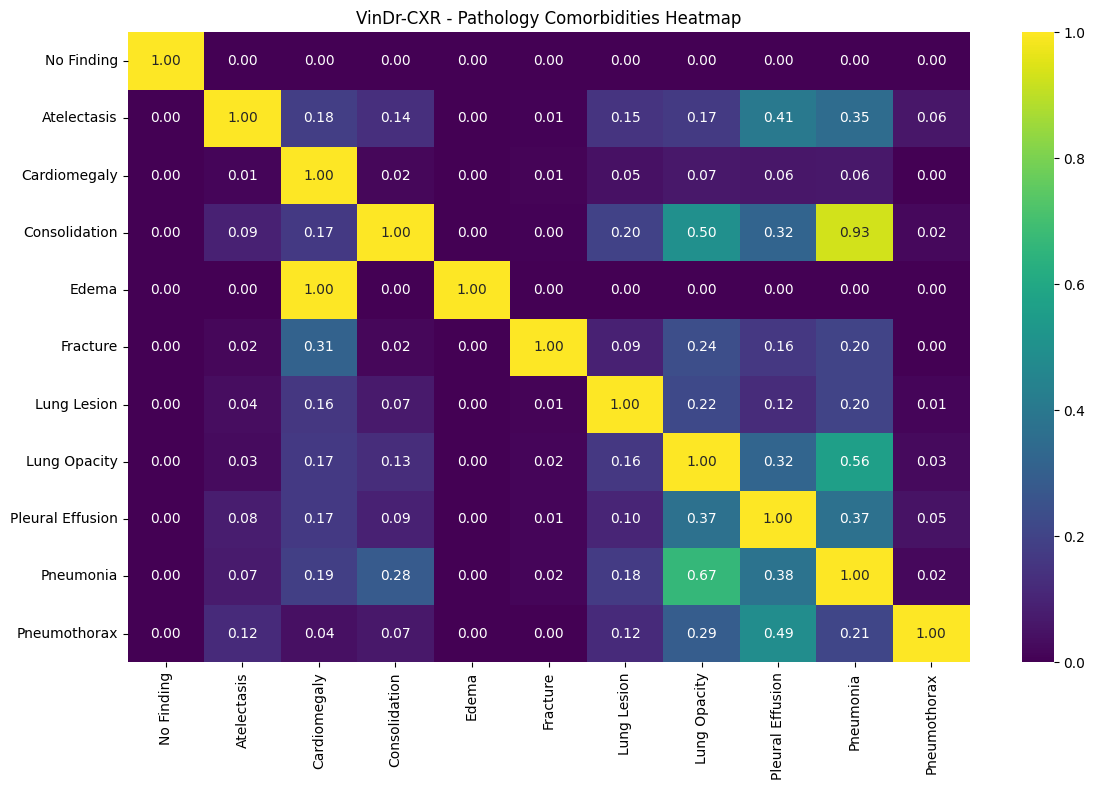

In [21]:
conditional_matrix = conditional_probability_matrix(majority_vote_df)
majority_vote_df.to_csv("conditional_probability_matrix_vindr.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("VinDr-CXR - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("vindr_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()

### CheXpert

In [126]:
#remove_nofinding_matrix = remove_nofinding.drop('No finding', axis=1)
label_cols = ['No Finding', 'Frontal/Lateral', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
chex_image_sheet = image_sheet[label_cols]

chex_image_sheet = chex_image_sheet[chex_image_sheet['Frontal/Lateral'] != "Lateral"]
chex_image_sheet = chex_image_sheet.drop('Frontal/Lateral', axis=1)

chex_image_sheet = chex_image_sheet.rename(columns={"Enlarged Cardiomediastinum": "Enlarged Cardio."})

In [127]:
chex_image_sheet

,No Finding,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardio.,Fracture,Lung Lesion,Lung Opacity,Pleural Effusion,Pneumonia,Pneumothorax,Support Devices
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
223410,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
223411,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
223412,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


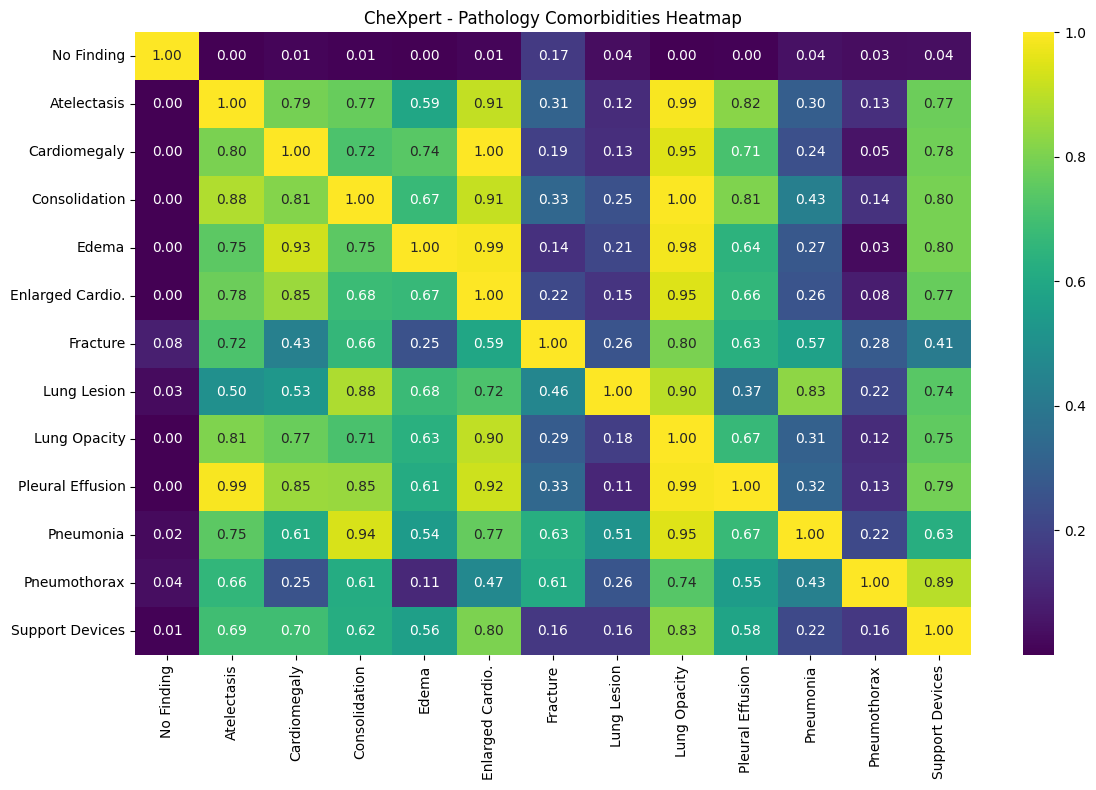

In [128]:
conditional_matrix = conditional_probability_matrix(chex_image_sheet)
chex_image_sheet.to_csv("conditional_probability_matrix_chexpert.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("CheXpert - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("chexpert_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()

### MIMIC-CXR

In [33]:
label_cols = ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
mimic_image_sheet = mimic_duplicate_filtered_nofinding[label_cols]
mimic_image_sheet = mimic_image_sheet.rename(columns={"Enlarged Cardiomediastinum": "Enlarged Cardio."})

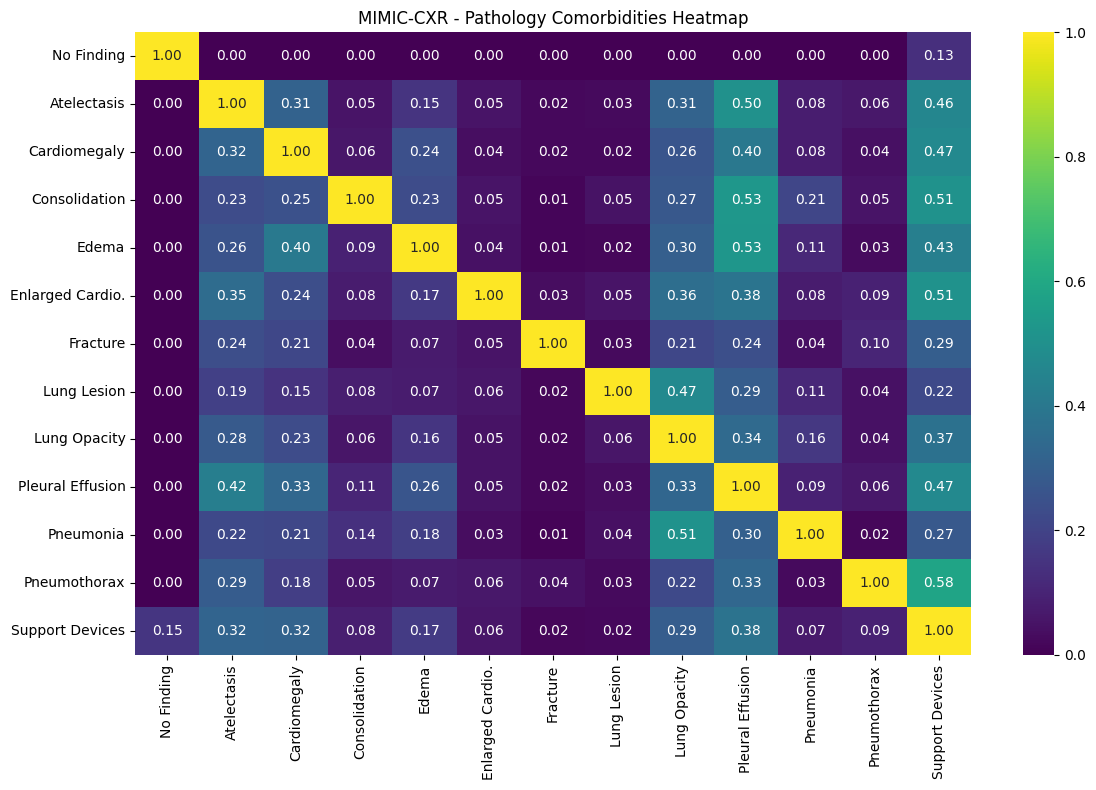

In [34]:
conditional_matrix = conditional_probability_matrix(mimic_image_sheet)
mimic_image_sheet.to_csv("conditional_probability_matrix_mimic.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("MIMIC-CXR - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("mimic_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()

### NIH ChestXRay14

In [50]:
nih_final_sheet = nih_final_sheet.copy()
nih_final_sheet["Mass"] = nih_final_sheet[["Mass", "Nodule"]].max(axis=1)
nih_final_sheet = nih_final_sheet.drop(columns=["Nodule"])

In [51]:
label_cols = ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Mass', 'Infiltration', 'Effusion', 'Pneumonia', 'Pneumothorax']
nih_final_sheet = nih_final_sheet[label_cols]
nih_final_sheet = nih_final_sheet.rename(columns={"Mass": "Lung Lesion"})
nih_final_sheet = nih_final_sheet.rename(columns={"Infiltration": "Lung Opacity"})

In [52]:
nih_final_sheet

,No Finding,Atelectasis,Cardiomegaly,Consolidation,Edema,Lung Lesion,Lung Opacity,Effusion,Pneumonia,Pneumothorax
0,0,0,1,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
112115,0,0,0,0,0,1,0,0,1,0
112116,1,0,0,0,0,0,0,0,0,0
112117,1,0,0,0,0,0,0,0,0,0
112118,1,0,0,0,0,0,0,0,0,0


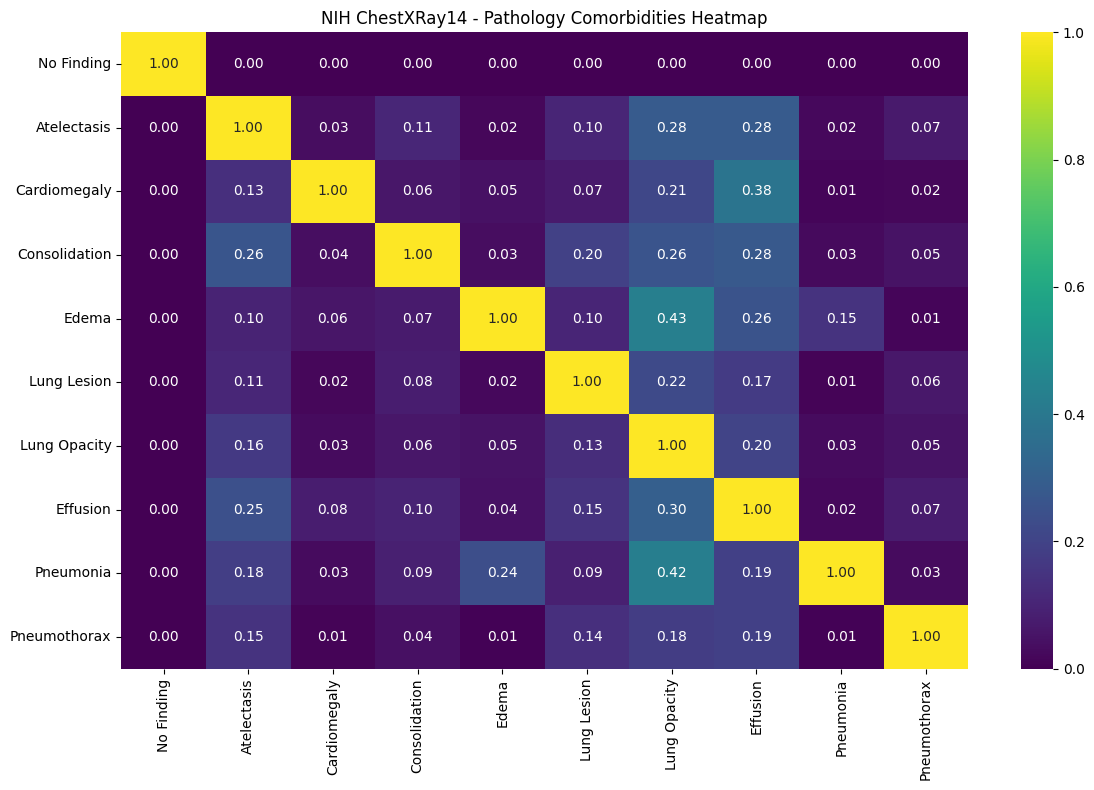

In [54]:
conditional_matrix = conditional_probability_matrix(nih_final_sheet)
nih_final_sheet.to_csv("conditional_probability_matrix_nih.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("NIH ChestXRay14 - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("nih_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()

### Brax

In [116]:
label_cols = ['ViewPosition', 'No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
brax_image_sheet = brax_sheet[label_cols]

brax_image_sheet = brax_image_sheet[(brax_image_sheet['ViewPosition'] == "PA") | (brax_image_sheet['ViewPosition'] == "AP")]
brax_image_sheet = brax_image_sheet.drop('ViewPosition', axis=1)

brax_image_sheet = brax_image_sheet.rename(columns={"Enlarged Cardiomediastinum": "Enlarged Cardio."})

In [117]:
brax_image_sheet

,No Finding,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardio.,Fracture,Lung Lesion,Lung Opacity,Pleural Effusion,Pneumonia,Pneumothorax,Support Devices
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40957,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40959,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40961,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
40963,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


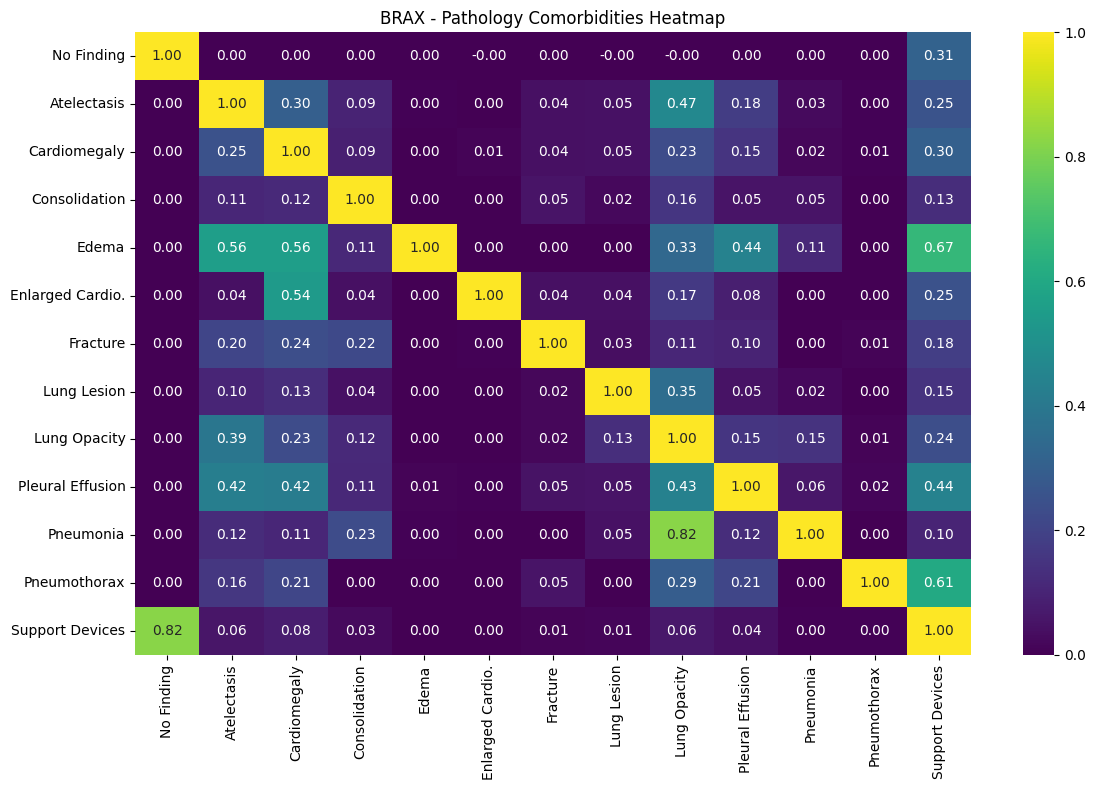

In [118]:
conditional_matrix = conditional_probability_matrix(brax_image_sheet)
brax_image_sheet.to_csv("conditional_probability_matrix_brax.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("BRAX - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("brax_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()

### Open-I

In [102]:
# Load the data label directory files
csv1_dir = r"indiana_projections.csv"
csv2_dir = r"indiana_reports.csv"

projection_sheet = pd.read_csv(csv1_dir)
reports_sheet = pd.read_csv(csv2_dir)

In [107]:
# Merge the two sheets with UID
merged_sheet = pd.merge(projection_sheet, reports_sheet, on='uid', how='inner')
column_kept = ['filename', 'Problems', 'projection']
filtered_simple_sheet = merged_sheet[column_kept]

filtered_simple_sheet = filtered_simple_sheet[filtered_simple_sheet['projection'] != "Lateral"]
filtered_simple_sheet = filtered_simple_sheet.drop('projection', axis=1)
filtered_simple_sheet

,filename,Problems
0,1_IM-0001-4001.dcm.png,normal
2,2_IM-0652-1001.dcm.png,Cardiomegaly;Pulmonary Artery
4,3_IM-1384-1001.dcm.png,normal
6,4_IM-2050-1001.dcm.png,"Pulmonary Disease, Chronic Obstructive;Bullous..."
8,5_IM-2117-1003002.dcm.png,Osteophyte;Thickening;Lung
...,...,...
7456,3995_IM-2046-1001.dcm.png,Lung;Diaphragm;Cicatrix;Pulmonary Atelectasis;...
7458,3996_IM-2047-1001.dcm.png,Spine
7460,3997_IM-2048-1001.dcm.png,Opacity;Granuloma
7462,3998_IM-2048-1001.dcm.png,normal


In [108]:
def merge_case_insensitive_columns(df):
    # Map lowercase column names to their original variants
    col_map = {}
    for col in df.columns:
        key = col.lower()
        col_map.setdefault(key, []).append(col)

    # Build merged columns
    merged_cols = []
    for key, variants in col_map.items():
        if len(variants) == 1:
            col = df[variants[0]].copy()
            col.name = variants[0]
        else:
            col = df[variants].max(axis=1)
            col.name = key.title()
        merged_cols.append(col)

    # Concatenate all columns at once to avoid fragmentation
    merged_df = pd.concat(merged_cols, axis=1)

    return merged_df

def safe_split(x):
    if isinstance(x, str):
        return [item.strip() for item in x.split(';') if item.strip()]
    elif isinstance(x, list):
        return [str(item).strip() for item in x if str(item).strip()]
    else:
        return []

filtered_simple_sheet = filtered_simple_sheet.copy()
filtered_simple_sheet['Problems'] = filtered_simple_sheet['Problems'].apply(safe_split)
expanded_sheet = filtered_simple_sheet['Problems'].apply(lambda x: pd.Series(1, index=set(x))).fillna(0)
filtered_simple_sheet = filtered_simple_sheet.drop(columns='Problems').join(expanded_sheet)
filtered_simple_sheet = merge_case_insensitive_columns(filtered_simple_sheet)
filtered_simple_sheet

,filename,normal,Pulmonary Artery,Cardiomegaly,Cicatrix,Bullous Emphysema,Pulmonary Fibrosis,"Pulmonary Disease, Chronic Obstructive",Opacity,Lung,...,Contrast Media,Hypovolemia,Abdomen,Lymph Nodes,Cavitation,Subcutaneous Emphysema,Hemopneumothorax,Bronchiolitis,Blood Vessels,Hemothorax
0,1_IM-0001-4001.dcm.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2_IM-0652-1001.dcm.png,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3_IM-1384-1001.dcm.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,4_IM-2050-1001.dcm.png,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,5_IM-2117-1003002.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7456,3995_IM-2046-1001.dcm.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7458,3996_IM-2047-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7460,3997_IM-2048-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7462,3998_IM-2048-1001.dcm.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [109]:
filtered_simple_sheet["Pneumothorax"] = filtered_simple_sheet[["Pneumothorax", "Subcutaneous Emphysema", "Hydropneumothorax", "Hemopneumothorax"]].max(axis=1)
filtered_simple_sheet["Pulmonary Atelectasis"] = filtered_simple_sheet[["Pulmonary Atelectasis", "Volume Loss"]].max(axis=1)
filtered_simple_sheet["Pulmonary Edema"] = filtered_simple_sheet[["Pulmonary Edema", "Pulmonary Congestion"]].max(axis=1)
filtered_simple_sheet["Opacity"] = filtered_simple_sheet[["Opacity", "Airspace Disease", "Density", "Infiltrate", "Pulmonary Fibrosis", "Fibrosis"]].max(axis=1)
filtered_simple_sheet["Mass"] = filtered_simple_sheet[["Mass", "Cicatrix", "Cavitation", "Granuloma", "Calcified Granuloma", "Granulomatous Disease", "Nodule", "Cysts", "Emphysema", "Bullous Emphysema", "Pulmonary Emphysema", "Sarcoidosis"]].max(axis=1)
filtered_simple_sheet["Thickening"] = filtered_simple_sheet[["Thickening", "Diaphragmatic Eventration"]].max(axis=1)
filtered_simple_sheet["Pleural Effusion"] = filtered_simple_sheet[["Pleural Effusion", "Hemothorax"]].max(axis=1)
filtered_simple_sheet["Medical Device"] = filtered_simple_sheet[["Medical Device", "Catheters, Indwelling", "Tube, Inserted", "Stents", "Implanted Medical Device"]].max(axis=1)
filtered_simple_sheet["Aorta"] = filtered_simple_sheet[["Aorta", "Heart Failure", "Cardiac Shadow", "Aorta, Thoracic", "Aortic Aneurysm"]].max(axis=1)
filtered_simple_sheet["Hernia, Diaphragmatic"] = filtered_simple_sheet[["Hernia, Diaphragmatic", "Hernia, Hiatal"]].max(axis=1)

# Drop combined columns
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Subcutaneous Emphysema", "Hydropneumothorax", "Hemopneumothorax"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Volume Loss"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Pulmonary Congestion"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Airspace Disease", "Density", "Infiltrate", "Pulmonary Fibrosis", "Fibrosis"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Cicatrix", "Cavitation", "Granuloma", "Calcified Granuloma", "Granulomatous Disease", "Nodule", "Cysts", "Emphysema", "Bullous Emphysema", "Pulmonary Emphysema", "Sarcoidosis"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Hemothorax"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Catheters, Indwelling", "Tube, Inserted", "Stents", "Implanted Medical Device"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Heart Failure", "Cardiac Shadow", "Aorta, Thoracic", "Aortic Aneurysm"])
filtered_simple_sheet = filtered_simple_sheet.drop(columns=["Hernia, Hiatal"])

In [110]:
label_cols = ['filename', 'normal', 'Pulmonary Atelectasis', 'Cardiomegaly', 'Consolidation', 'Pulmonary Edema', 'Aorta', 'Fractures, Bone', 'Mass', 'Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Medical Device']

openi_image_sheet = filtered_simple_sheet[label_cols]
openi_image_sheet = openi_image_sheet.rename(columns={"Aorta": "Enlarged Cardio."})
openi_image_sheet = openi_image_sheet.rename(columns={"Pulmonary Edema": "Edema"})
openi_image_sheet = openi_image_sheet.rename(columns={"Pulmonary Atelectasis": "Atelectasis"})
openi_image_sheet = openi_image_sheet.rename(columns={"normal": "No Finding"})
openi_image_sheet = openi_image_sheet.rename(columns={"Fractures, Bone": "Fracture"})
openi_image_sheet = openi_image_sheet.rename(columns={"Mass": "Lung Lesion"})
openi_image_sheet = openi_image_sheet.rename(columns={"Opacity": "Lung Opacity"})
openi_image_sheet = openi_image_sheet.rename(columns={"Medical Device": "Support Devices"})

In [60]:
train_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/openi_train_split.csv")
selection_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/openi_selection_split.csv")
test_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/openi_test_split.csv")
test_split_sheet

,filename,normal,Pulmonary Artery,Cardiomegaly,Opacity,"Pulmonary Disease, Chronic Obstructive",Osteophyte,Thickening,Lung,Pulmonary Atelectasis,...,"Trachea, Carina",Bronchitis,Thorax,Contrast Media,Hypovolemia,Abdomen,Lymph Nodes,Subcutaneous Emphysema,Bronchiolitis,Blood Vessels
0,2_IM-0652-2001.dcm.png,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13_IM-0198-2001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23_IM-0879-1001.dcm.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,32_IM-1511-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,36_IM-1776-2001.dcm.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,3988_IM-2041-1001.dcm.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
743,3989_IM-2042-1001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
744,3989_IM-2042-2001.dcm.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
745,3994_IM-2045-1001.dcm.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
final_openi_train_split = openi_image_sheet[openi_image_sheet["filename"].isin(train_split_sheet["filename"])]
final_openi_selection_split = openi_image_sheet[openi_image_sheet["filename"].isin(selection_split_sheet["filename"])]
final_openi_test_split = openi_image_sheet[openi_image_sheet["filename"].isin(test_split_sheet["filename"])]

final_openi_train_split["filename"] = final_openi_train_split["filename"].str.replace(".dcm.png", "", regex=False)
final_openi_selection_split["filename"] = final_openi_selection_split["filename"].str.replace(".dcm.png", "", regex=False)
final_openi_test_split["filename"] = final_openi_test_split["filename"].str.replace(".dcm.png", "", regex=False)

final_openi_train_split["filename"] = "CXR" + final_openi_train_split["filename"].astype(str)
final_openi_selection_split["filename"] = "CXR" + final_openi_selection_split["filename"].astype(str)
final_openi_test_split["filename"] = "CXR" + final_openi_test_split["filename"].astype(str)

final_openi_train_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/openi_train_split.csv", index=False)
final_openi_selection_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/openi_selection_split.csv", index=False)
final_openi_test_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/openi_test_split.csv", index=False)

/tmp/ipykernel_2638373/81275651.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_openi_train_split["filename"] = final_openi_train_split["filename"].str.replace(".dcm.png", "", regex=False)
/tmp/ipykernel_2638373/81275651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_openi_selection_split["filename"] = final_openi_selection_split["filename"].str.replace(".dcm.png", "", regex=False)
/tmp/ipykernel_2638373/81275651.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

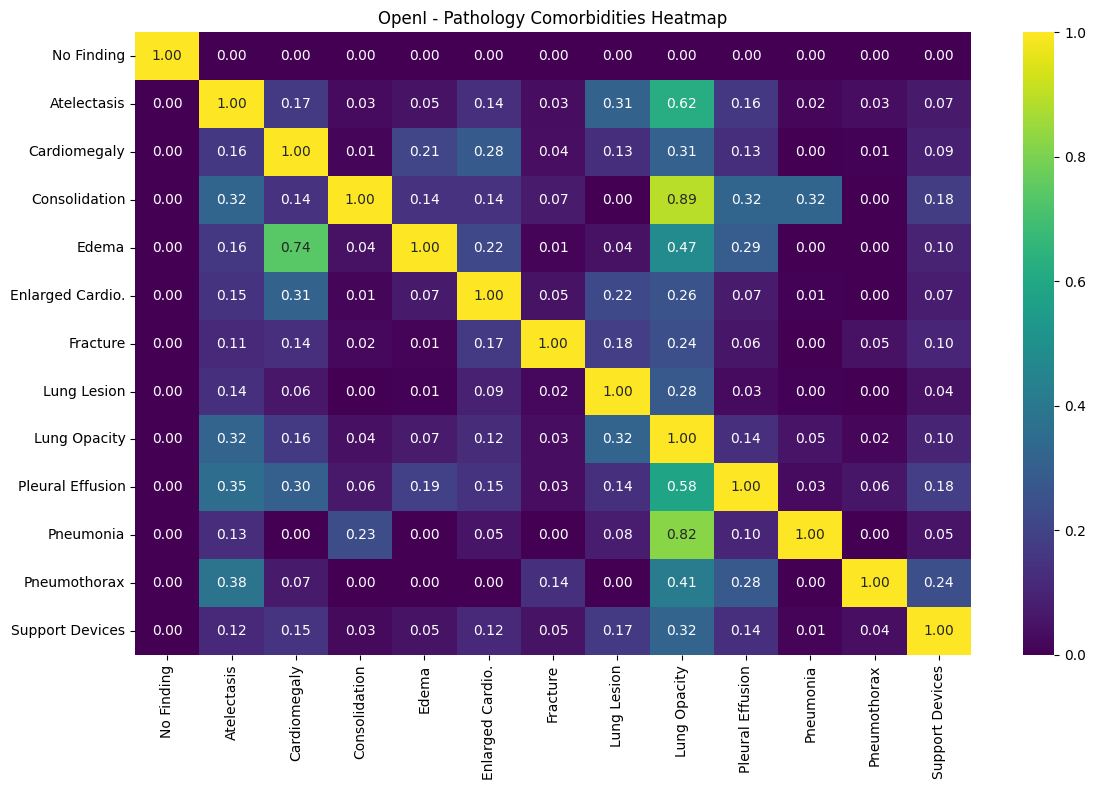

In [111]:
openi_image_sheet = openi_image_sheet.drop('filename', axis=1)
conditional_matrix = conditional_probability_matrix(openi_image_sheet)
openi_image_sheet.to_csv("conditional_probability_matrix_openi.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("OpenI - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("openi_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()

### PadChest

In [93]:
# Load the data label directory files
csv_dir = r"padchest_chest_x_ray_images_labels_160K_01.02.19.csv"

image_sheet = pd.read_csv(csv_dir)
column_kept = ['ImageID', 'ImageDir', 'PatientID', 'Projection', 'Labels']
filter_sheet = image_sheet[column_kept]
filter_sheet

,ImageID,ImageDir,PatientID,Projection,Labels
0,20536686640136348236148679891455886468_k6ga29.png,0,839860488694292331637988235681460987,PA,['normal']
1,135803415504923515076821959678074435083_fzis7d...,0,313572750430997347502932654319389875966,L,"['pulmonary fibrosis', 'chronic changes', 'kyp..."
2,135803415504923515076821959678074435083_fzis7b...,0,313572750430997347502932654319389875966,PA,"['pulmonary fibrosis', 'chronic changes', 'kyp..."
3,113855343774216031107737439268243531979_3k951l...,0,50783093527901818115346441867348318648,PA,['chronic changes']
4,113855343774216031107737439268243531979_3k951n...,0,50783093527901818115346441867348318648,L,['chronic changes']
...,...,...,...,...,...
160856,1284011361929414522814654121696751542351444145...,49,112930952416074060371371014599496493673,PA,"['COPD signs', 'costophrenic angle blunting']"
160857,1284011361929414522094646571696751542351444145...,49,282743729971423358706056731890510600934,PA,['normal']
160858,1284011361929414522086390631696751542351444145...,49,52648743308541843883453242716226652771,AP_horizontal,"['NSG tube', ' endotracheal tube']"
160859,1284011361929414522084108901696751542351444145...,49,228646130593152933811948996634154201216,PA,['normal']


In [94]:
# Break down all the labels with one-hot Encoding
import ast

# Step 1: Convert stringified lists to actual Python lists
filter_sheet = filter_sheet.copy()
filter_sheet['Labels'] = filter_sheet['Labels'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Step 2: Expand into binary columns
expanded_sheet = filter_sheet['Labels'].apply(lambda x: pd.Series(1, index=x)).fillna(0)

# Step 3: Merge with original DataFrame
padchest_final_sheet = filter_sheet.drop(columns='Labels').join(expanded_sheet)

In [95]:
# Filter out Lateral images & unnecessary columns
padchest_final_sheet = padchest_final_sheet[padchest_final_sheet['Projection'] != "L"]
padchest_final_sheet = padchest_final_sheet.drop(['ImageDir', 'Projection'], axis=1)
padchest_final_sheet

,ImageID,PatientID,normal,pulmonary fibrosis,chronic changes,kyphosis,pseudonodule,ground glass pattern,unchanged,alveolar pattern,...,gastrostomy tube,round atelectasis,aortic endoprosthesis,azygoesophageal recess shift,catheter,subacromial space narrowing,central venous catheter via umbilical vein,pleural plaques,asbestosis signs,mastectomy
0,20536686640136348236148679891455886468_k6ga29.png,839860488694292331637988235681460987,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,135803415504923515076821959678074435083_fzis7b...,313572750430997347502932654319389875966,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,113855343774216031107737439268243531979_3k951l...,50783093527901818115346441867348318648,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,313903302629300007485735352869488750471_75sg0k...,3707275269754751392247446521222810702,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,3137231742710829928-247610802266403640553_kine...,93535126770783451980359712286922420997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160856,1284011361929414522814654121696751542351444145...,112930952416074060371371014599496493673,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160857,1284011361929414522094646571696751542351444145...,282743729971423358706056731890510600934,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160858,1284011361929414522086390631696751542351444145...,52648743308541843883453242716226652771,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160859,1284011361929414522084108901696751542351444145...,228646130593152933811948996634154201216,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
# Check duplicates causes by space -- eg. "fracture" and " fracture"
# Strip column names to normalize
padchest_final_sheet.columns = padchest_final_sheet.columns.str.strip()

# Track original column names before stripping
original_cols = padchest_final_sheet.columns.tolist()
raw_cols = padchest_final_sheet.columns.str.strip().tolist()

# Find duplicates caused by spacing
from collections import Counter
col_counts = Counter(raw_cols)

# Merge columns with same stripped name
for col in col_counts:
    if col_counts[col] > 1:
        # Find all variants of this column name
        variants = [c for c in original_cols if c.strip() == col]
        # Merge them: 1 if any variant is 1, else 0
        padchest_final_sheet[col] = padchest_final_sheet[variants].fillna(0).astype(int).max(axis=1)
        # Drop all but one
        to_drop = [c for c in variants if c != col]
        padchest_final_sheet.drop(columns=to_drop, inplace=True)

# Merge column with insensitive same columns name
padchest_final_sheet = merge_case_insensitive_columns(padchest_final_sheet)
padchest_final_sheet

,ImageID,PatientID,Normal,Pulmonary Fibrosis,Chronic Changes,Kyphosis,Pseudonodule,Ground Glass Pattern,Unchanged,Alveolar Pattern,...,pneumomediastinum,Catheter,Surgery Humeral,empyema,nephrostomy tube,sternoclavicular junction hypertrophy,Pulmonary Venous Hypertension,Gastrostomy Tube,lipomatosis,
0,20536686640136348236148679891455886468_k6ga29.png,839860488694292331637988235681460987,1,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
2,135803415504923515076821959678074435083_fzis7b...,313572750430997347502932654319389875966,0,1,1,1,1,1,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
3,113855343774216031107737439268243531979_3k951l...,50783093527901818115346441867348318648,0,0,1,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
5,313903302629300007485735352869488750471_75sg0k...,3707275269754751392247446521222810702,0,0,0,0,0,0,1,1,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
7,3137231742710829928-247610802266403640553_kine...,93535126770783451980359712286922420997,0,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160856,1284011361929414522814654121696751542351444145...,112930952416074060371371014599496493673,0,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
160857,1284011361929414522094646571696751542351444145...,282743729971423358706056731890510600934,1,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
160858,1284011361929414522086390631696751542351444145...,52648743308541843883453242716226652771,0,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0
160859,1284011361929414522084108901696751542351444145...,228646130593152933811948996634154201216,1,0,0,0,0,0,0,0,...,0.0,0,0,0.0,0.0,0.0,0,0,0.0,0.0


In [97]:
# Merge the columns to avoid double counting
padchest_final_sheet["Pneumonia"] = padchest_final_sheet[["Pneumonia", "Atypical Pneumonia"]].max(axis=1)
padchest_final_sheet["Pneumothorax"] = padchest_final_sheet[["Pneumothorax", "air fluid level", "Hydropneumothorax"]].max(axis=1)
padchest_final_sheet["Atelectasis"] = padchest_final_sheet[["Atelectasis", "Laminar Atelectasis", "Segmental Atelectasis", "Lobar Atelectasis", "atelectasis basal", "Total Atelectasis", "Round Atelectasis", "Flattened Diaphragm", "Volume Loss", "hypoexpansion basal", "Hypoexpansion"]].max(axis=1)
padchest_final_sheet["Cardiomegaly"] = padchest_final_sheet[["Cardiomegaly", "Heart Insufficiency"]].max(axis=1)
padchest_final_sheet["Pulmonary Edema"] = padchest_final_sheet[["Pulmonary Edema", "Kerley Lines"]].max(axis=1)
padchest_final_sheet["Infiltrates"] = padchest_final_sheet[["Infiltrates", "Alveolar Pattern", "Interstitial Pattern", "Ground Glass Pattern", "Reticulonodular Interstitial Pattern", "Reticular Interstitial Pattern", "Bronchovascular Markings", "Miliary Opacities"]].max(axis=1)
padchest_final_sheet["Pulmonary Mass"] = padchest_final_sheet[["Pulmonary Mass", "Mass", "Soft Tissue Mass", "pleural mass", "Nodule", "Multiple Nodules", "Cavitation", "Calcified Adenopathy", "Lymphangitis Carcinomatosa", "Lepidic Adenocarcinoma", "Bone Metastasis", "Lung Metastasis", "Tuberculosis Sequelae", "Pulmonary Fibrosis", "Calcified Granuloma", "Granuloma", "cyst"]].max(axis=1)
padchest_final_sheet["Pleural Thickening"] = padchest_final_sheet[["Pleural Thickening", "Calcified Pleural Thickening", "Apical Pleural Thickening", "Major Fissure Thickening", "Minor Fissure Thickening", "Fissure Thickening", "Pleural Plaques", "Calcified Pleural Plaques", "Diaphragmatic Eventration"]].max(axis=1)
padchest_final_sheet["Pleural Effusion"] = padchest_final_sheet[["Pleural Effusion", "Loculated Fissural Effusion"]].max(axis=1)
padchest_final_sheet["Endotracheal Tube"] = padchest_final_sheet[["Endotracheal Tube", "Tracheostomy Tube", "NSG tube", "Single Chamber Device", "Dual Chamber Device", "Electrical Device", "Central Venous Catheter Via Subclavian Vein", "Central Venous Catheter", "Reservoir Central Venous Catheter", "Central Venous Catheter Via Jugular Vein", "Central Venous Catheter Via Umbilical Vein", "Catheter", "double J stent", "Chest Drain Tube", "Gastrostomy Tube", "Ventriculoperitoneal Drain Tube", "Artificial Heart Valve", "Artificial Mitral Heart Valve", "Artificial Aortic Heart Valve", "Pacemaker", "bone cement", "endoprosthesis", "Aortic Endoprosthesis"]].max(axis=1)
padchest_final_sheet["fracture"] = padchest_final_sheet[["fracture", "Clavicle Fracture", "Callus Rib Fracture", "Humeral Fracture", "Vertebral Fracture", "Rib Fracture"]].max(axis=1)
padchest_final_sheet["Aortic Elongation"] = padchest_final_sheet[["Aortic Elongation", "Supra Aortic Elongation", "Descendent Aortic Elongation", "Ascendent Aortic Elongation", "Mediastinal Enlargement", "Pulmonary Artery Enlargement", "Aortic Button Enlargement", "Superior Mediastinal Enlargement", "Mediastinal Shift"]].max(axis=1)
padchest_final_sheet["abnormal foreign body"] = padchest_final_sheet[["abnormal foreign body", "External Foreign Body", "Metal", "Suture Material", "Osteosynthesis Material"]].max(axis=1)

# Drop combined columns
padchest_final_sheet = padchest_final_sheet.drop(columns=["Atypical Pneumonia"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["air fluid level", "Hydropneumothorax"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Laminar Atelectasis", "Segmental Atelectasis", "Lobar Atelectasis", "atelectasis basal", "Total Atelectasis", "Round Atelectasis", "Flattened Diaphragm", "Volume Loss", "hypoexpansion basal", "Hypoexpansion"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Heart Insufficiency"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Kerley Lines"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Alveolar Pattern", "Interstitial Pattern", "Ground Glass Pattern", "Reticulonodular Interstitial Pattern", "Reticular Interstitial Pattern", "Bronchovascular Markings", "Miliary Opacities"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Mass", "Soft Tissue Mass", "pleural mass", "Nodule", "Multiple Nodules", "Cavitation", "Calcified Adenopathy", "Lymphangitis Carcinomatosa", "Lepidic Adenocarcinoma", "Bone Metastasis", "Lung Metastasis", "Tuberculosis Sequelae", "Pulmonary Fibrosis", "Calcified Granuloma", "Granuloma", "cyst"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Calcified Pleural Thickening", "Apical Pleural Thickening", "Major Fissure Thickening", "Minor Fissure Thickening", "Fissure Thickening", "Pleural Plaques", "Calcified Pleural Plaques", "Diaphragmatic Eventration"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Loculated Fissural Effusion"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Tracheostomy Tube", "NSG tube", "Single Chamber Device", "Dual Chamber Device", "Electrical Device", "Central Venous Catheter Via Subclavian Vein", "Central Venous Catheter", "Reservoir Central Venous Catheter", "Central Venous Catheter Via Jugular Vein", "Central Venous Catheter Via Umbilical Vein", "Catheter", "double J stent", "Chest Drain Tube", "Gastrostomy Tube", "Ventriculoperitoneal Drain Tube", "Artificial Heart Valve", "Artificial Mitral Heart Valve", "Artificial Aortic Heart Valve", "Pacemaker", "bone cement", "endoprosthesis", "Aortic Endoprosthesis"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Clavicle Fracture", "Callus Rib Fracture", "Humeral Fracture", "Vertebral Fracture", "Rib Fracture"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["Supra Aortic Elongation", "Descendent Aortic Elongation", "Ascendent Aortic Elongation", "Mediastinal Enlargement", "Pulmonary Artery Enlargement", "Aortic Button Enlargement", "Superior Mediastinal Enlargement", "Mediastinal Shift"])
padchest_final_sheet = padchest_final_sheet.drop(columns=["External Foreign Body", "Metal", "Suture Material", "Osteosynthesis Material"])

In [98]:
label_cols = ['ImageID', 'Normal', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Pulmonary Edema', 'Aortic Elongation', 'fracture', 'Pulmonary Mass', 'Infiltrates', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Endotracheal Tube']
padchest_image_sheet = padchest_final_sheet[label_cols]

padchest_image_sheet = padchest_image_sheet.rename(columns={"Normal": "No Finding"})
padchest_image_sheet = padchest_image_sheet.rename(columns={"Pulmonary Edema": "Edema"})
padchest_image_sheet = padchest_image_sheet.rename(columns={"Aortic Elongation": "Enlarged Cardio."})
padchest_image_sheet = padchest_image_sheet.rename(columns={"fracture": "Fracture"})
padchest_image_sheet = padchest_image_sheet.rename(columns={"Pulmonary Mass": "Lung Lesion"})
padchest_image_sheet = padchest_image_sheet.rename(columns={"Infiltrates": "Lung Opacity"})
padchest_image_sheet = padchest_image_sheet.rename(columns={"Endotracheal Tube": "Support Devices"})

In [70]:
train_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/images/image_load/pc_train_split_xrv.csv")
selection_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/images/image_load/pc_selection_split_xrv.csv")
test_split_sheet = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/images/image_load/pc_test_split_xrv.csv")
train_split_sheet

,Unnamed: 0,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,...,ExposureTime,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,...,10.0,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[]
1,1,135803415504923515076821959678074435083_fzis7d...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,LATERAL,L,...,25.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
2,2,135803415504923515076821959678074435083_fzis7b...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,POSTEROANTERIOR,PA,...,10.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
3,3,113855343774216031107737439268243531979_3k951l...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,POSTEROANTERIOR,PA,...,8.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
4,4,113855343774216031107737439268243531979_3k951n...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,LATERAL,L,...,20.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128506,160854,1284011361929414522079841201696751542351444145...,49,20090714,1284011361929414522079841201696751542351444145...,178941107688363238116741298870229076976,1958.0,F,LATERAL,L,...,25.0,0.00,3611530,motiv consult neo mam seguimient . radiografi...,RNN_model,['normal'],[],"['exclude', 'normal', 'normal']",[],[]
128507,160855,1284011361929414522814654121696751542351444145...,49,20110321,1284011361929414522814654121696751542351444145...,112930952416074060371371014599496493673,1948.0,M,LATERAL,L,...,25.0,0.64,4018689,import sign radiolog epoc . pinzamient ambos ...,RNN_model,"['COPD signs', 'costophrenic angle blunting']",['loc costophrenic angle'],"['COPD signs', 'costophrenic angle blunting', ...",['C0024117' 'C0742855'],['C0230151']
128508,160856,1284011361929414522814654121696751542351444145...,49,20110321,1284011361929414522814654121696751542351444145...,112930952416074060371371014599496493673,1948.0,M,POSTEROANTERIOR,PA,...,10.0,-0.69,4018689,import sign radiolog epoc . pinzamient ambos ...,RNN_model,"['COPD signs', 'costophrenic angle blunting']",['loc costophrenic angle'],"['COPD signs', 'costophrenic angle blunting', ...",['C0024117' 'C0742855'],['C0230151']
128509,160857,1284011361929414522094646571696751542351444145...,49,20090609,1284011361929414522094646571696751542351444145...,282743729971423358706056731890510600934,1944.0,F,POSTEROANTERIOR,PA,...,10.0,-0.85,3639865,dentr normal .,RNN_model,['normal'],[],['normal'],[],[]


In [73]:
final_pc_train_split = padchest_image_sheet[padchest_image_sheet["ImageID"].isin(train_split_sheet["ImageID"])]
final_pc_selection_split = padchest_image_sheet[padchest_image_sheet["ImageID"].isin(selection_split_sheet["ImageID"])]
final_pc_test_split = padchest_image_sheet[padchest_image_sheet["ImageID"].isin(test_split_sheet["ImageID"])]

final_pc_train_split["ImageID"] = final_pc_train_split["ImageID"].str.replace(".png", "", regex=False)
final_pc_selection_split["ImageID"] = final_pc_selection_split["ImageID"].str.replace(".png", "", regex=False)
final_pc_test_split["ImageID"] = final_pc_test_split["ImageID"].str.replace(".png", "", regex=False)

final_pc_train_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/pc_train_split.csv", index=False)
final_pc_selection_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split.csv", index=False)
final_pc_test_split.to_csv("/home/varrel/GitHub/CXR-Analysis/final_csv/pc_test_split.csv", index=False)

/tmp/ipykernel_2638373/346159281.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_pc_train_split["ImageID"] = final_pc_train_split["ImageID"].str.replace(".png", "", regex=False)
/tmp/ipykernel_2638373/346159281.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_pc_selection_split["ImageID"] = final_pc_selection_split["ImageID"].str.replace(".png", "", regex=False)
/tmp/ipykernel_2638373/346159281.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [99]:
padchest_image_sheet

,ImageID,No Finding,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardio.,Fracture,Lung Lesion,Lung Opacity,Pleural Effusion,Pneumonia,Pneumothorax,Support Devices
0,20536686640136348236148679891455886468_k6ga29.png,1,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0
2,135803415504923515076821959678074435083_fzis7b...,0,0.0,0,0,0,0,0.0,1.0,1,0,0,0.0,0.0
3,113855343774216031107737439268243531979_3k951l...,0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0
5,313903302629300007485735352869488750471_75sg0k...,0,0.0,0,0,0,0,0.0,0.0,1,0,0,0.0,0.0
7,3137231742710829928-247610802266403640553_kine...,0,1.0,0,0,0,0,0.0,0.0,0,1,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160856,1284011361929414522814654121696751542351444145...,0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0
160857,1284011361929414522094646571696751542351444145...,1,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0
160858,1284011361929414522086390631696751542351444145...,0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,1.0
160859,1284011361929414522084108901696751542351444145...,1,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0


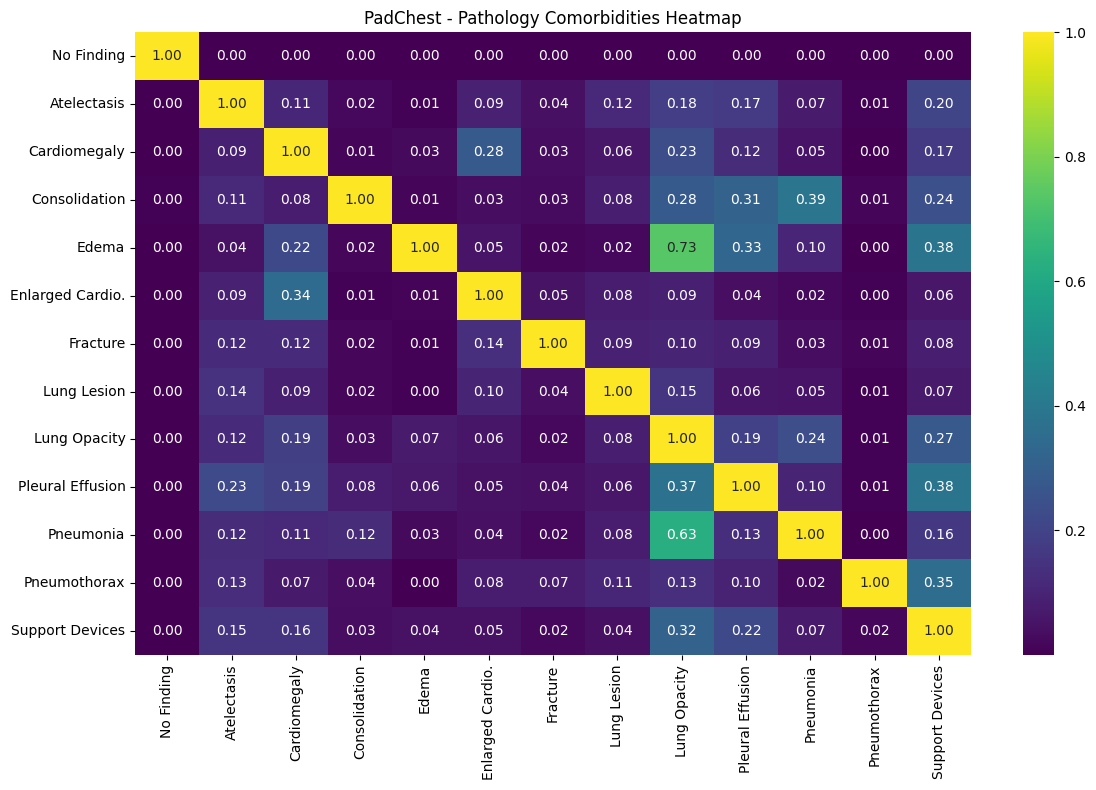

In [101]:
padchest_image_sheet = padchest_image_sheet.drop('ImageID', axis=1)
conditional_matrix = conditional_probability_matrix(padchest_image_sheet)
padchest_image_sheet.to_csv("conditional_probability_matrix_padchest.csv", index=False)

plt.figure(figsize=(12, 8))  # Optional: adjust size
sns.heatmap(conditional_matrix, annot=True, cmap='viridis', fmt=".2f")

plt.title("PadChest - Pathology Comorbidities Heatmap")
plt.tight_layout()
plt.savefig("padchest_pathology_comorbidities_heatmap.png", dpi=300)
plt.show()